# Inter-Rater Label Comparison (Quality Control)

This notebook assesses labeling consistency by comparing a ground truth (GT) labeler against other labelers.

## Metrics Computed

### 1. Image-Level Detection
Binary classification: Did the labeler detect ANY irrigation in the image?
- **TP**: Both GT and comparison labeled irrigation
- **FP**: Only comparison labeled (false alarm)
- **FN**: Only GT labeled (missed detection)  
- **TN**: Neither labeled
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)

### 2. Area Overlap
Continuous metric: How much do the labeled polygon areas agree?
- For each image, union all polygons per labeler
- **Precision** = intersection_area / comp_area (% of marked area that was correct)
- **Recall** = intersection_area / gt_area (% of GT area that was found)
- **IoU** = intersection_area / union_area
- Overall metrics sum areas across all images before computing ratios

## Output Files
All outputs are saved to the specified `output_dir`:
- `{op}_confusion_matrix.png` - Image detection confusion matrix
- `{op}_detection_metrics.png` - Detection metrics bar chart
- `{op}_area_metrics.png` - Area overlap bar chart
- `{op}_area_histograms.png` - Per-image metric distributions
- `{site_id}_{date}.png` - Side-by-side polygon comparison plots
- `image_detection_metrics.csv` - Summary table with weighted averages
- `area_overlap_metrics.csv` - Summary table with weighted averages

In [21]:
# Import the comparison class
import sys
sys.path.insert(0, '..')
from src.labels.label_comparison import LabelComparison

## Run Comparison: AB (Ground Truth) vs PS

In [22]:
# Define paths
irrigation_table_path = '../data/labels/labeled_surveys/random_sample/latest_irrigation_table.csv'
polygons_path = '../data/labels/labeled_surveys/random_sample/latest_polygons.geojson'
image_boundaries_path = '../data/labels/labeled_surveys/random_sample/latest_irrigation_data.geojson'

# Create comparison object comparing AB (ground truth) to all other labelers
# Figures will be automatically saved to the output directory
comparison = LabelComparison(
    irrigation_table_path=irrigation_table_path,
    polygons_path=polygons_path,
    image_boundaries_path=image_boundaries_path,
    gt_operator='PS',
    comparison_operators=['DSB', 'JL', 'KL', 'MV'], # , 'PS'],  # All other labelers
    min_certainty=4,  # Only include polygons with certainty above threshold
    date_tolerance_days=1,
    output_dir='../outputs/quality_control/ps_comparisons_cert_4'  # Save all figures here
)

Figures will be saved to: ../outputs/ps_comparisons_cert_4
Loading data for PS vs ['DSB', 'JL', 'KL', 'MV']...
  Loaded 2780 image labels, 3576 polygons
  PS: 204 images, 89 polygons
  DSB: 588 images, 626 polygons
  JL: 582 images, 1310 polygons
  KL: 681 images, 961 polygons
  MV: 623 images, 465 polygons
  Filtering by certainty >= 4...
Matching images (±1 day tolerance)...
  PS vs DSB: 86 matched images
  PS vs JL: 100 matched images
  PS vs KL: 47 matched images
  PS vs MV: 88 matched images


## Access and Analyze Results

## Generate Detection Metrics Plots

Generate plots on demand for any comparison operator.


Generating detection plots for DSB...
Saved: ../outputs/ps_comparisons_cert_4/DSB_confusion_matrix.png


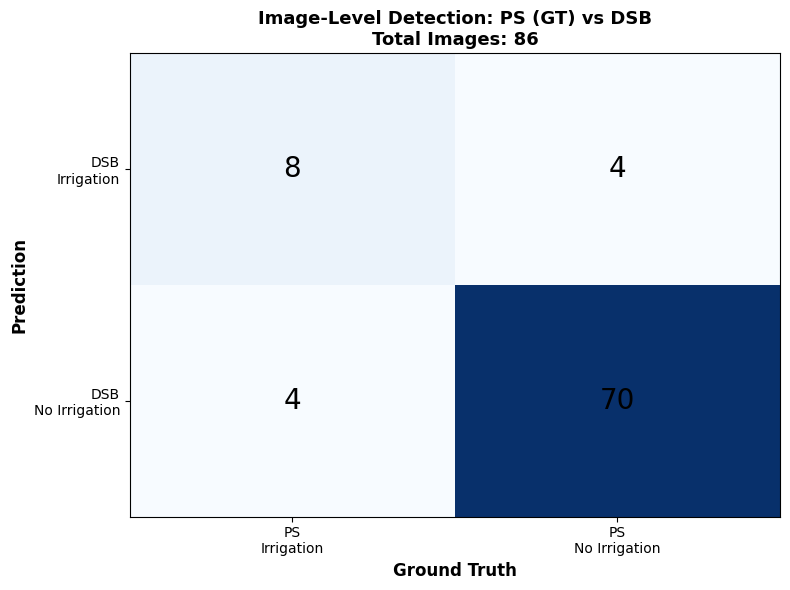

Saved: ../outputs/ps_comparisons_cert_4/DSB_detection_metrics.png


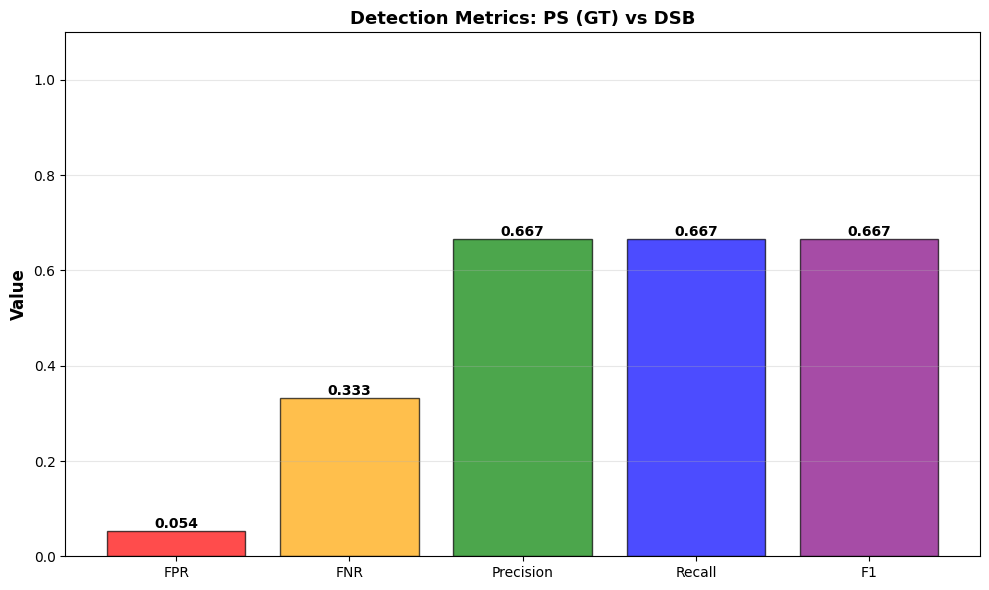


Generating detection plots for JL...
Saved: ../outputs/ps_comparisons_cert_4/JL_confusion_matrix.png


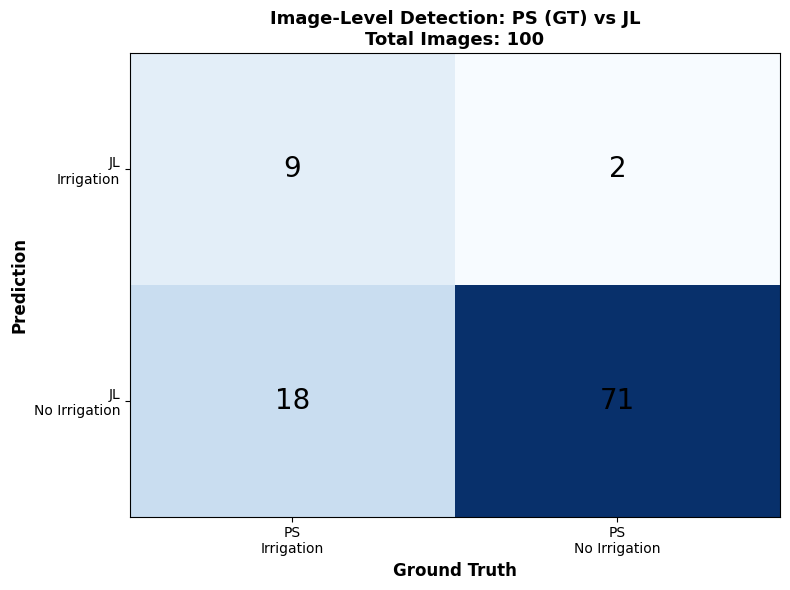

Saved: ../outputs/ps_comparisons_cert_4/JL_detection_metrics.png


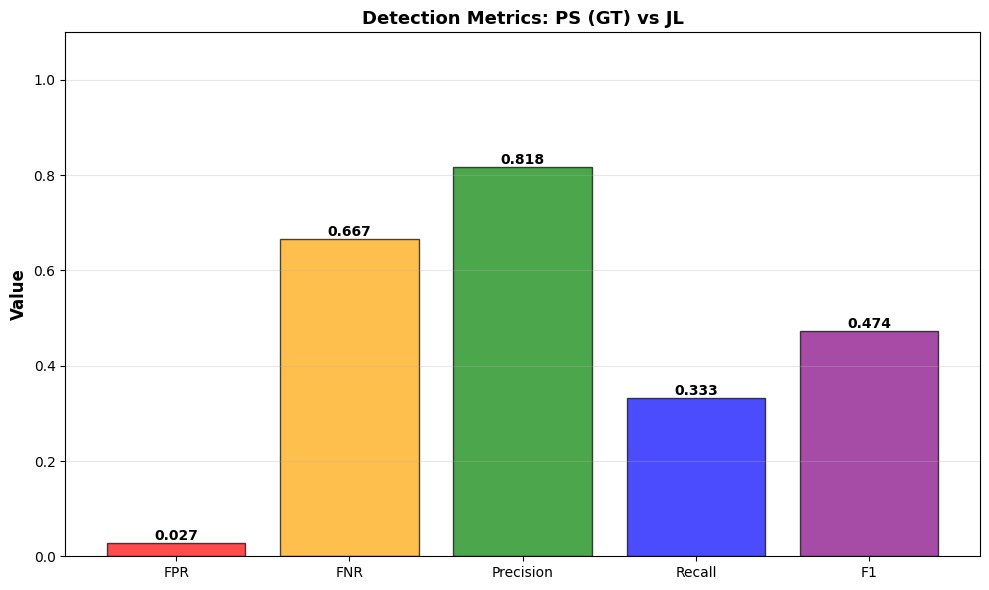


Generating detection plots for KL...
Saved: ../outputs/ps_comparisons_cert_4/KL_confusion_matrix.png


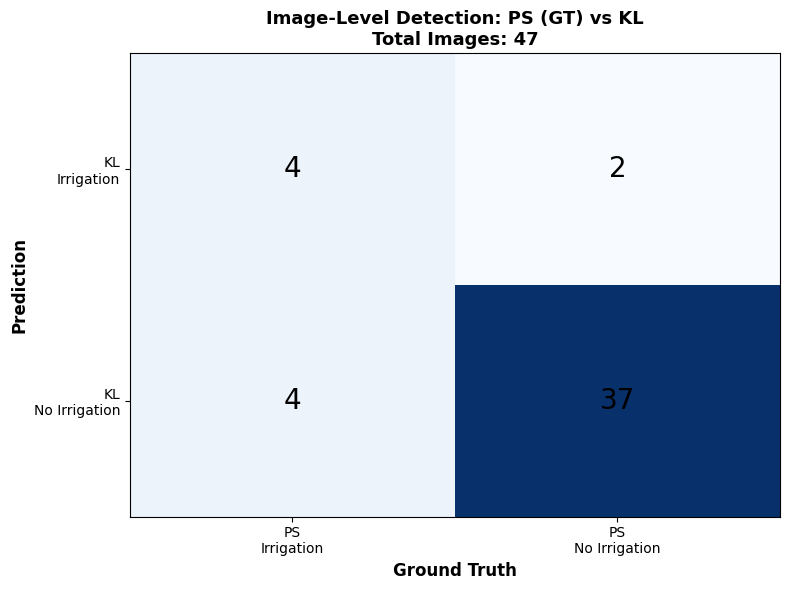

Saved: ../outputs/ps_comparisons_cert_4/KL_detection_metrics.png


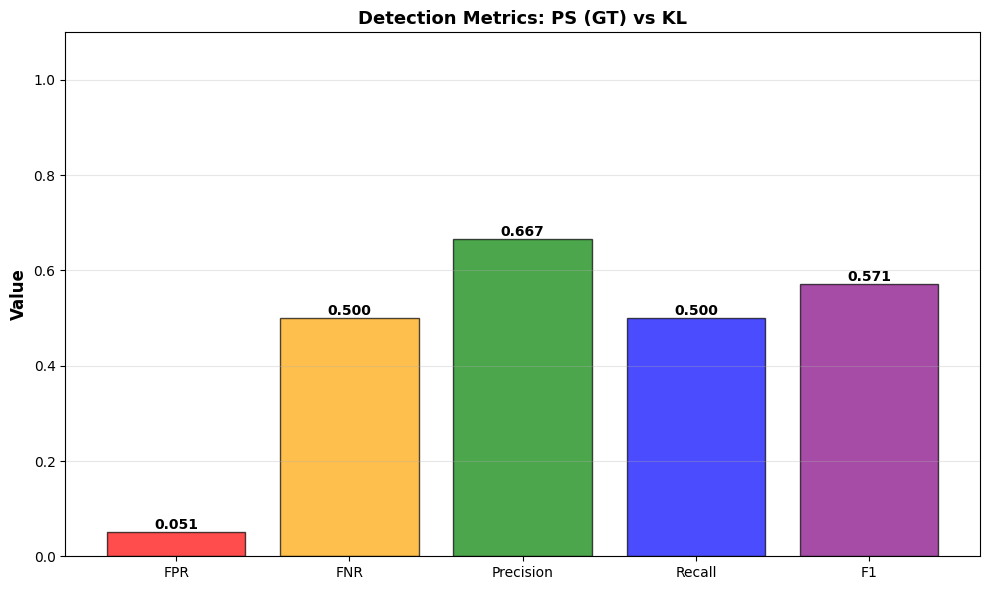


Generating detection plots for MV...
Saved: ../outputs/ps_comparisons_cert_4/MV_confusion_matrix.png


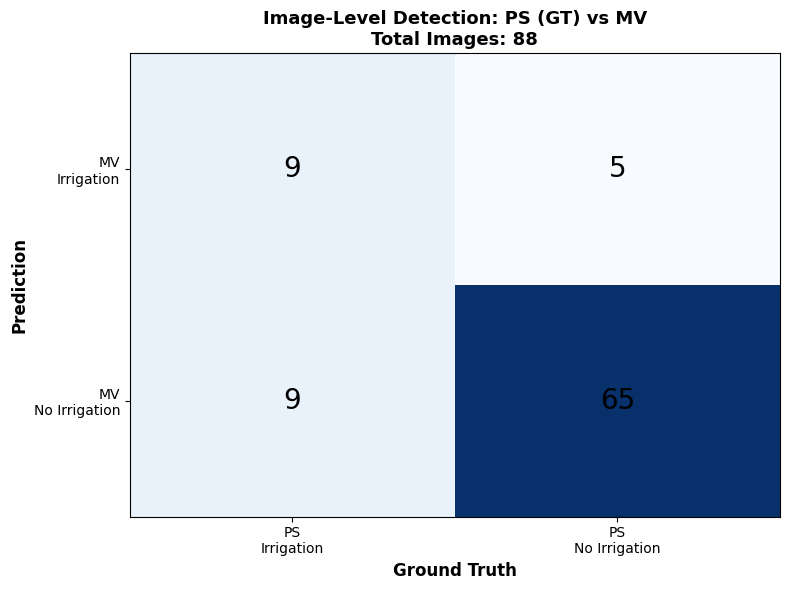

Saved: ../outputs/ps_comparisons_cert_4/MV_detection_metrics.png


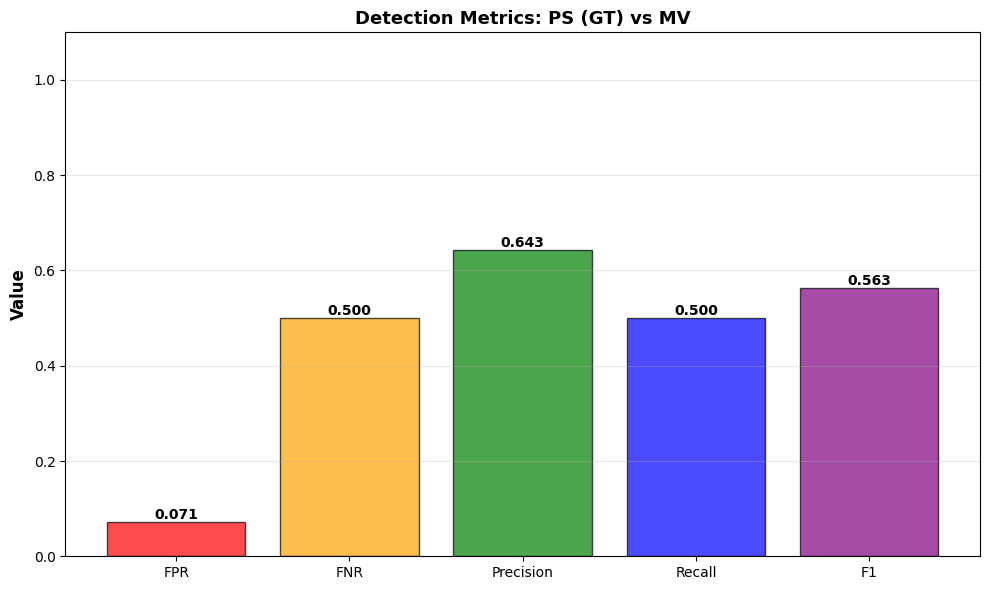

In [23]:
# Generate confusion matrices and detection metrics for all comparison operators
for op in comparison.comparison_operators:
    print(f"\nGenerating detection plots for {op}...")
    comparison.plot_confusion_matrix(op)
    comparison.plot_detection_metrics_bar(op)

## Generate Area Overlap Plots

View polygon-level area overlap metrics and histograms.


Generating area plots for DSB...
Saved: ../outputs/ps_comparisons_cert_4/DSB_area_metrics.png


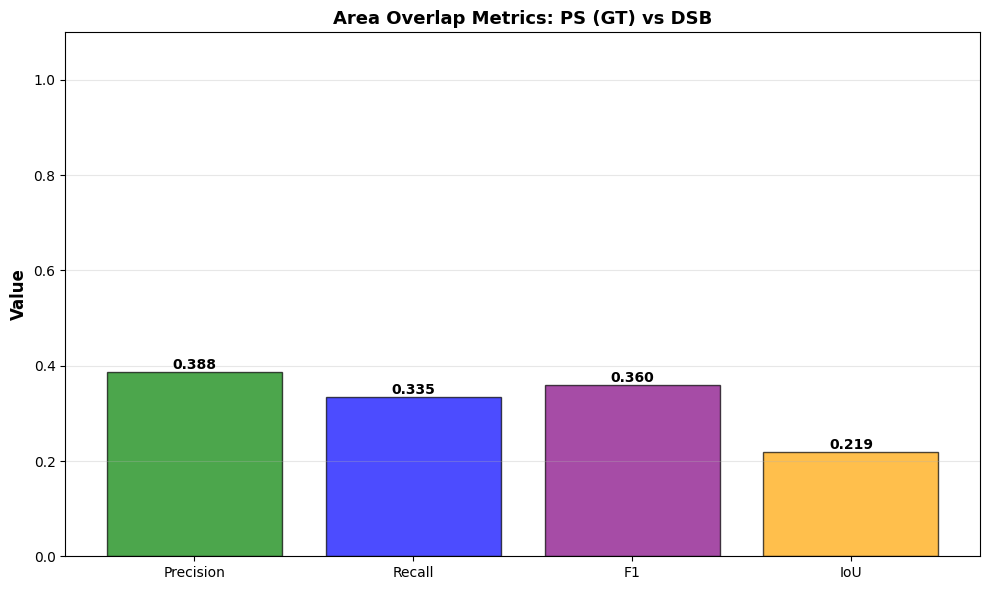

Saved: ../outputs/ps_comparisons_cert_4/DSB_area_histograms.png


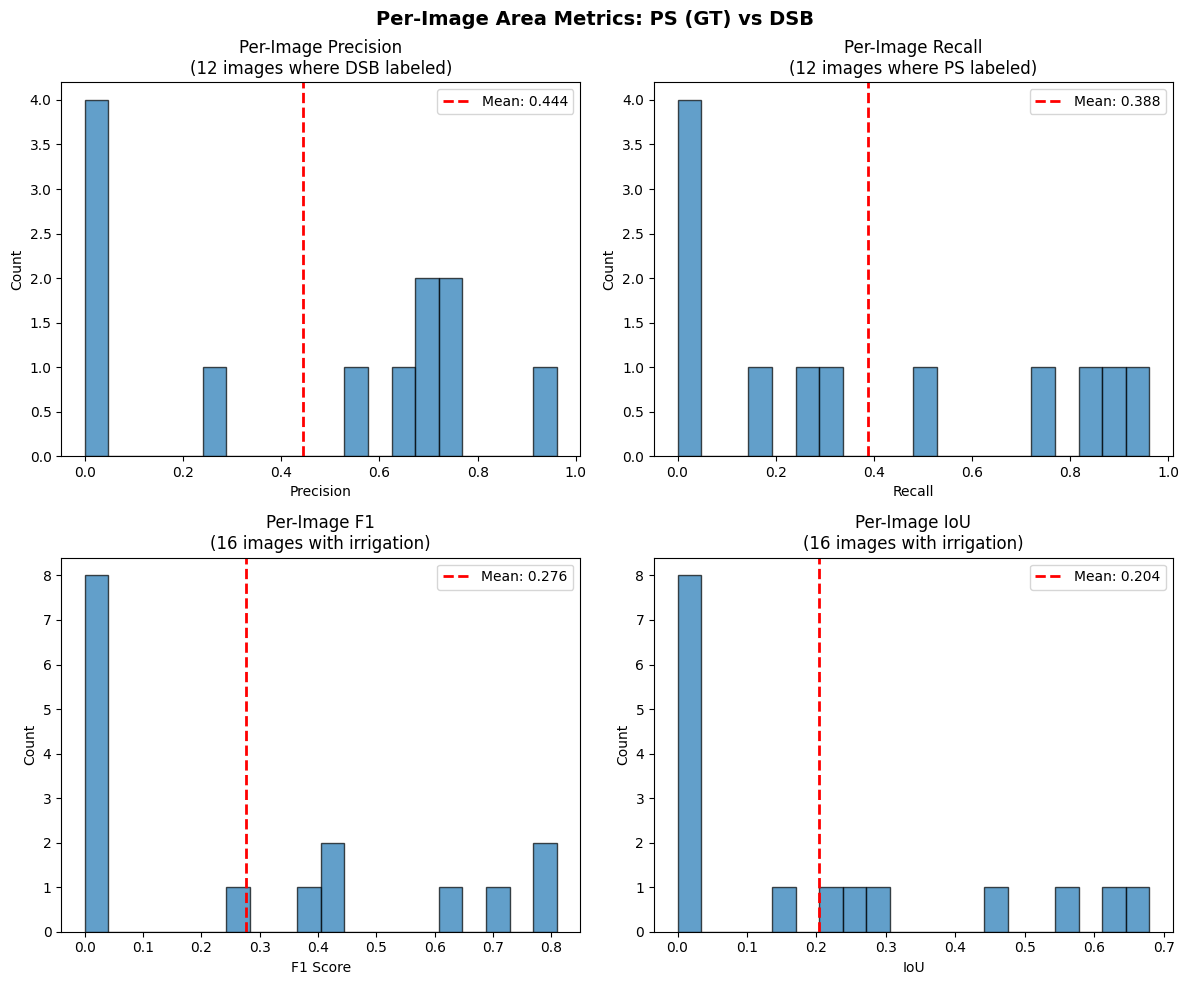


Generating area plots for JL...
Saved: ../outputs/ps_comparisons_cert_4/JL_area_metrics.png


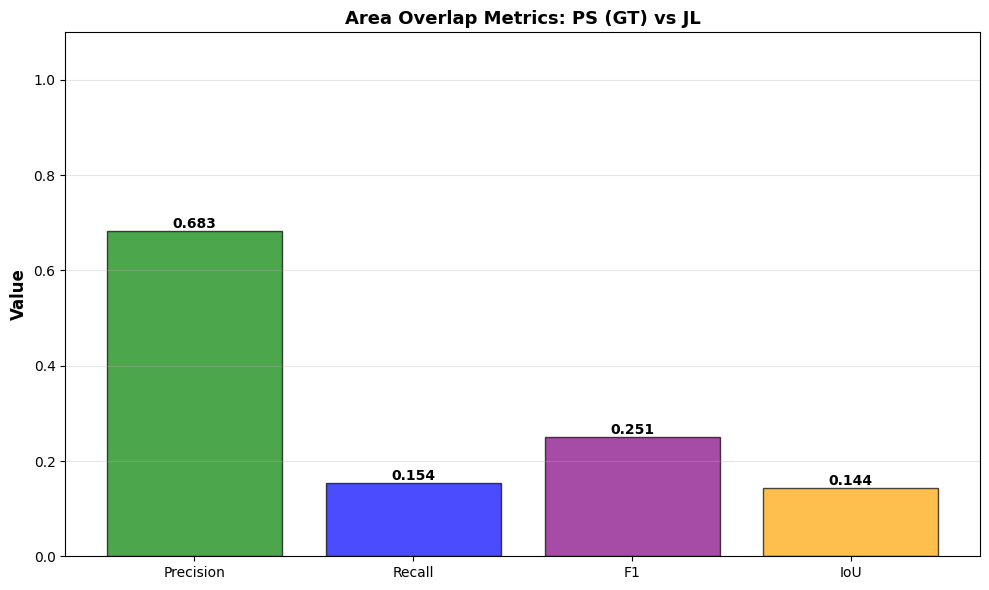

Saved: ../outputs/ps_comparisons_cert_4/JL_area_histograms.png


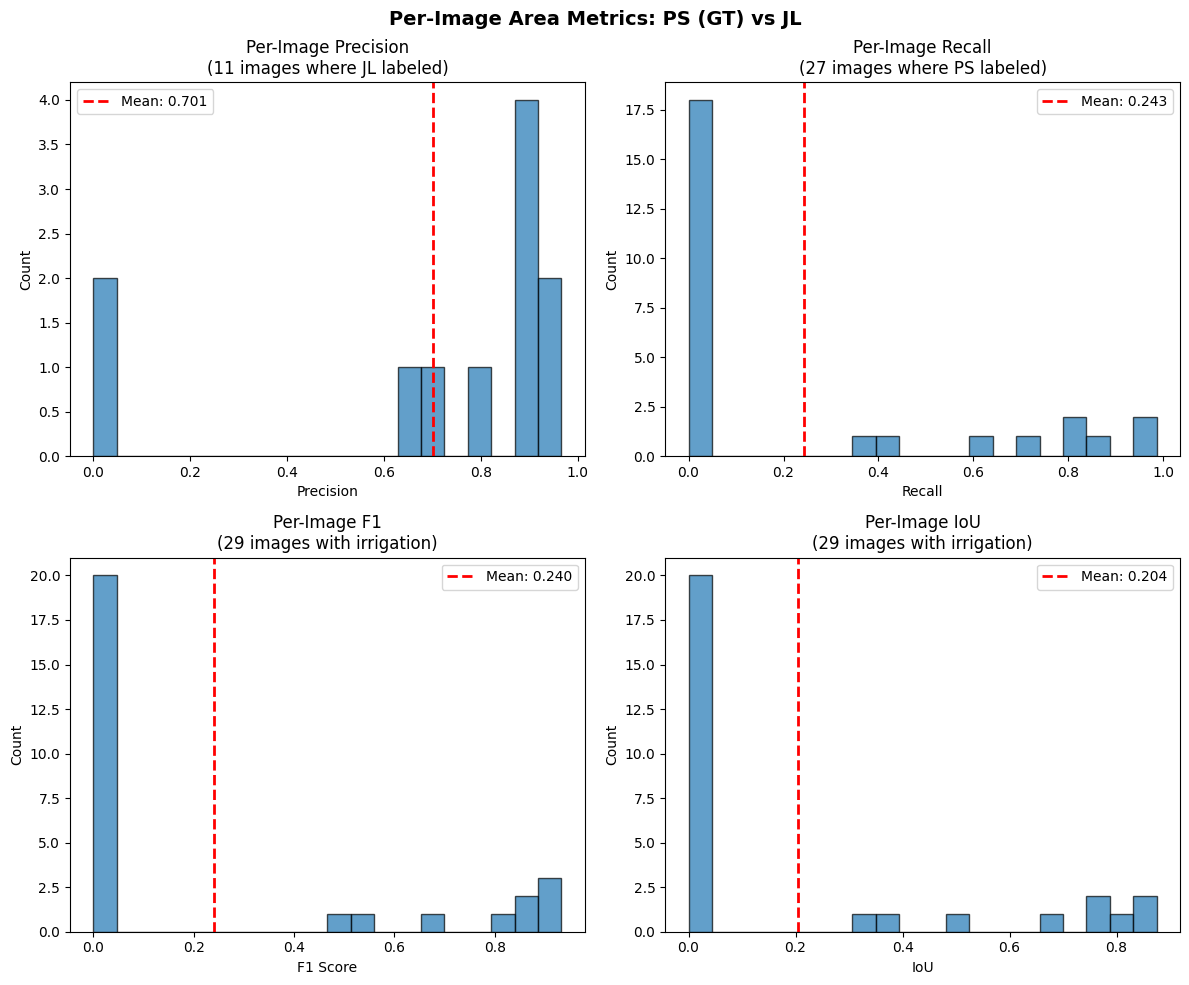


Generating area plots for KL...
Saved: ../outputs/ps_comparisons_cert_4/KL_area_metrics.png


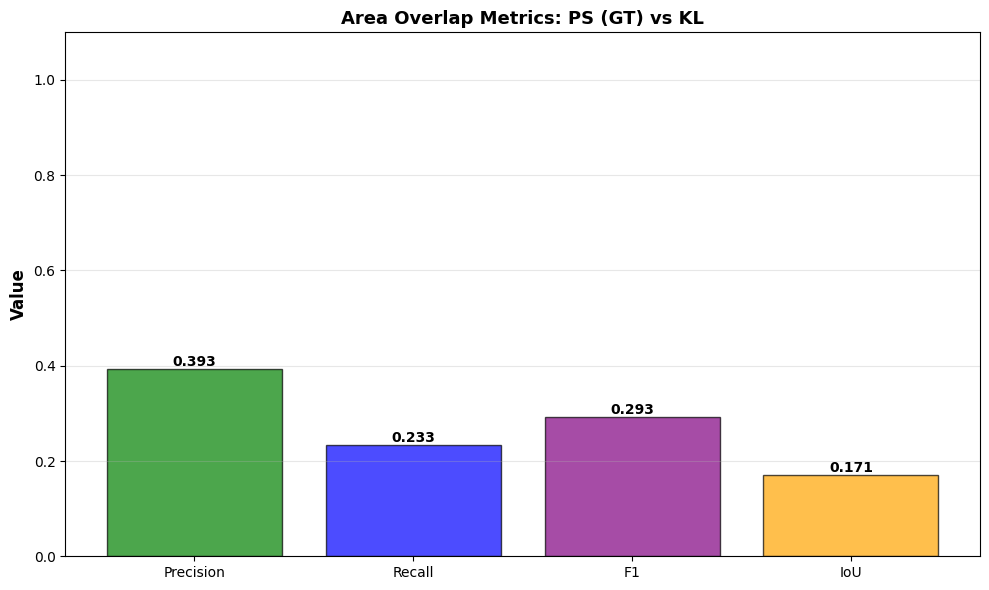

Saved: ../outputs/ps_comparisons_cert_4/KL_area_histograms.png


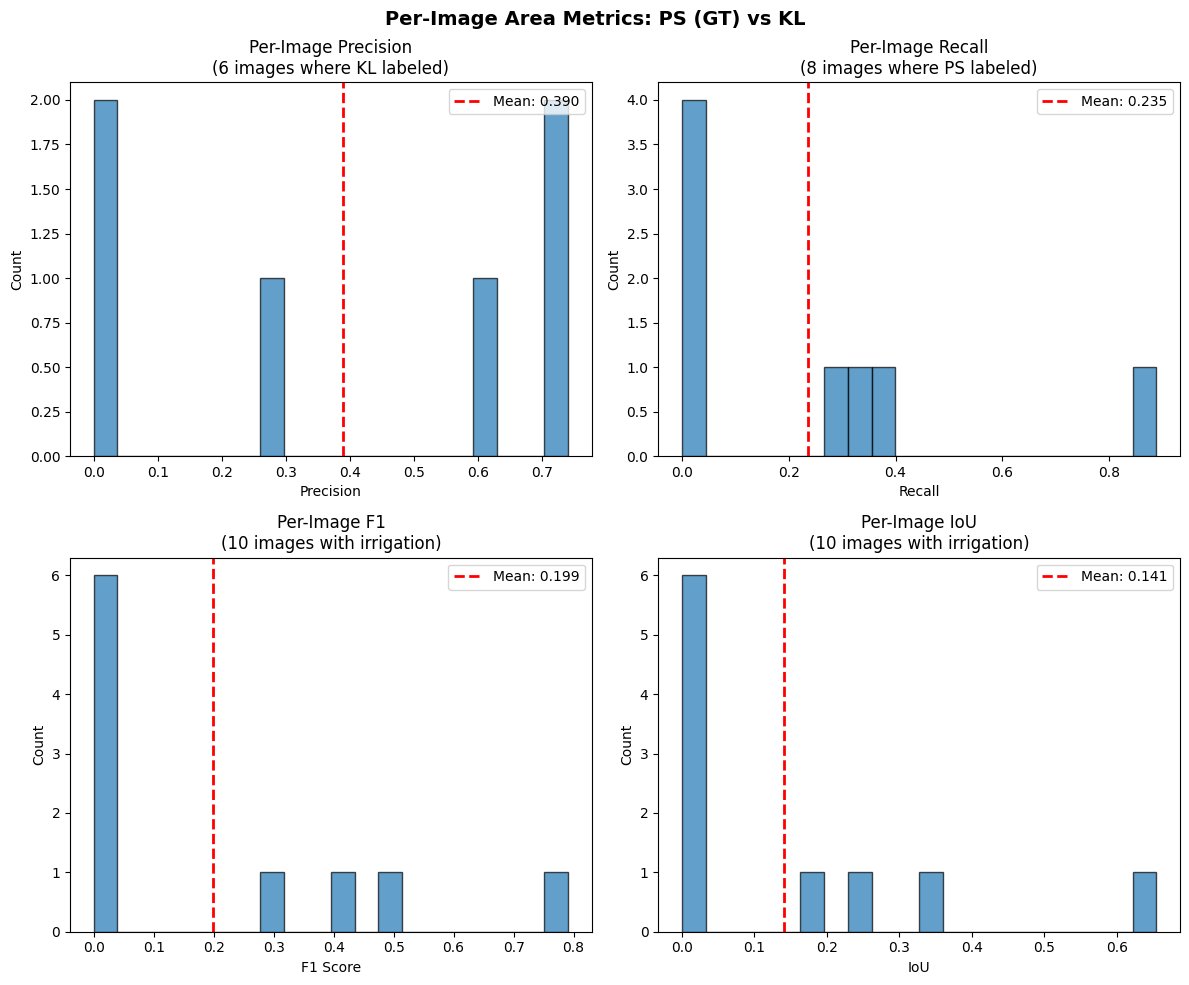


Generating area plots for MV...
Saved: ../outputs/ps_comparisons_cert_4/MV_area_metrics.png


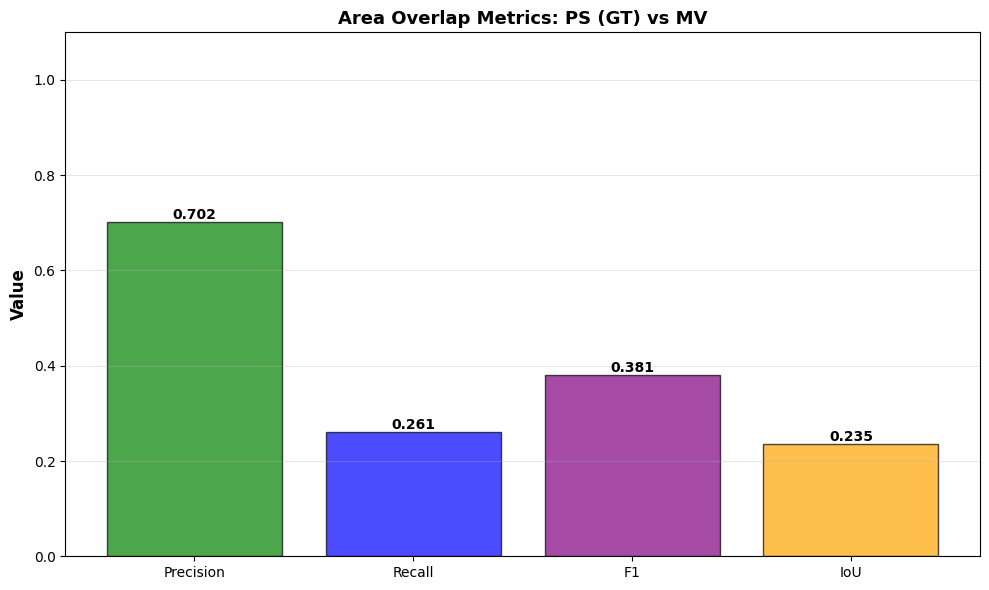

Saved: ../outputs/ps_comparisons_cert_4/MV_area_histograms.png


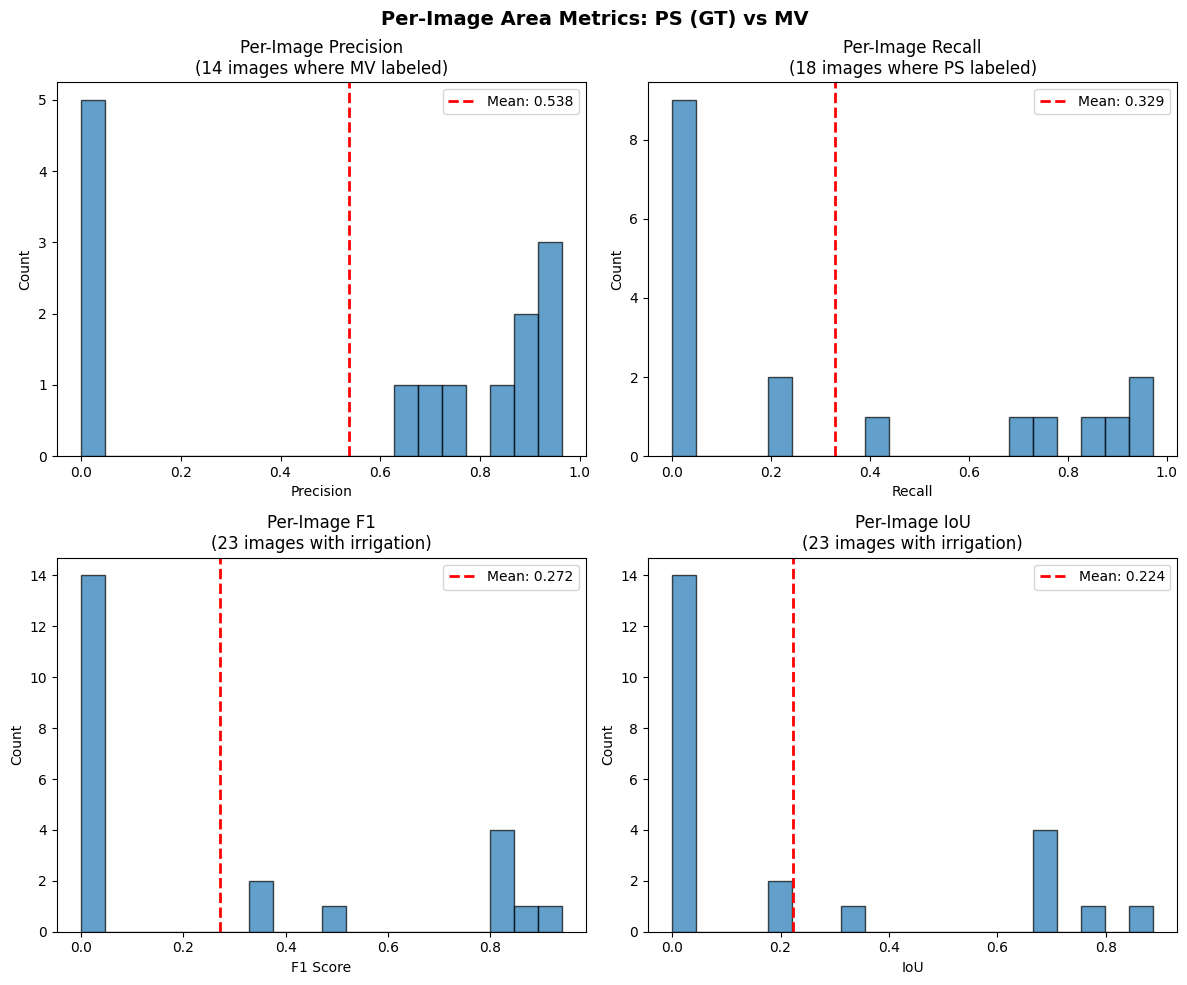

In [24]:
# Generate area overlap bar charts and histograms for all comparison operators
for op in comparison.comparison_operators:
    print(f"\nGenerating area plots for {op}...")
    comparison.plot_area_metrics_bar(op)  # New: bar chart of overall area metrics
    comparison.plot_area_histograms(op)   # Histograms of per-image area data

# # Access raw data for a specific operator if needed
# print("\nExample: Area data for PS")
# area_data = comparison.compute_area_metrics('PS')
# print(area_data[['site_id', 'n_gt', 'n_comp', 'gt_area', 'comp_area', 'intersection_area', 'union_area']].head())

# # Get overall metrics
# print("\nOverall area metrics for PS:")
# overall = comparison.compute_overall_area_metrics('PS')
# print(f"  Precision: {overall['precision']:.3f}")
# print(f"  Recall: {overall['recall']:.3f}")
# print(f"  IoU: {overall['iou']:.3f}")

## Plot Image Comparisons

Plot individual images or all matched images.

In [17]:
# # Plot a specific image
# matches = comparison.get_matches('PS')
# if len(matches) > 0:
#     first_match = matches.iloc[0]
#     comparison.plot_image_comparison(first_match['site_id'], first_match['gt_date'])


Plotting images with polygons...
Images will be saved to: ../outputs/ps_comparisons_cert_4
Plotting 47 images with polygons...


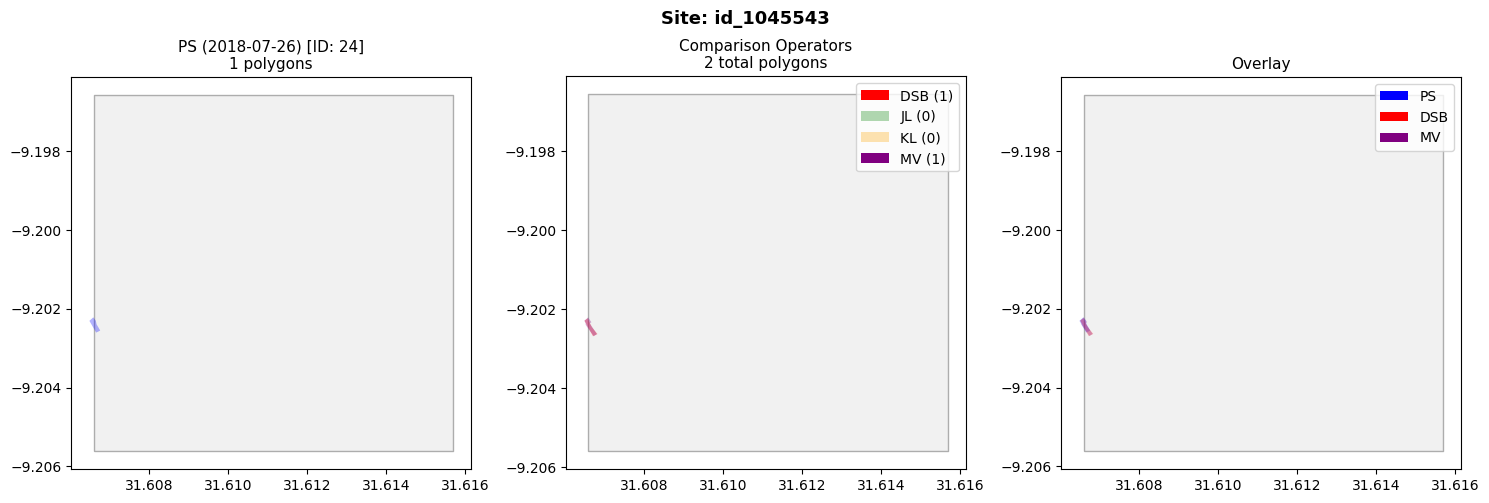

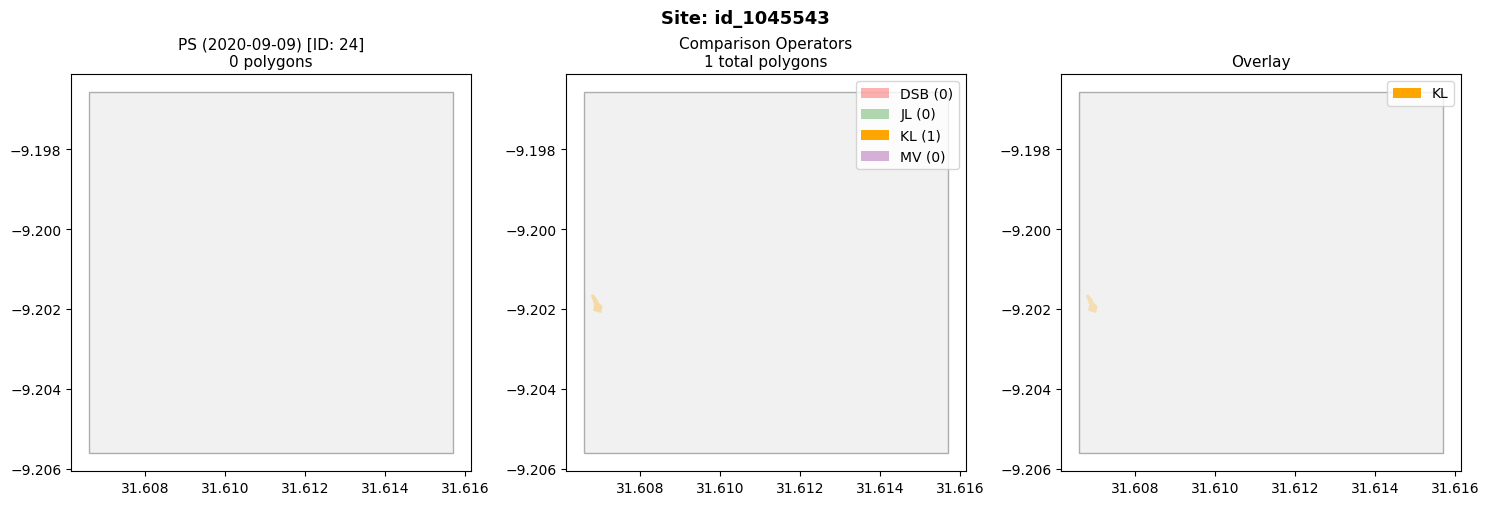

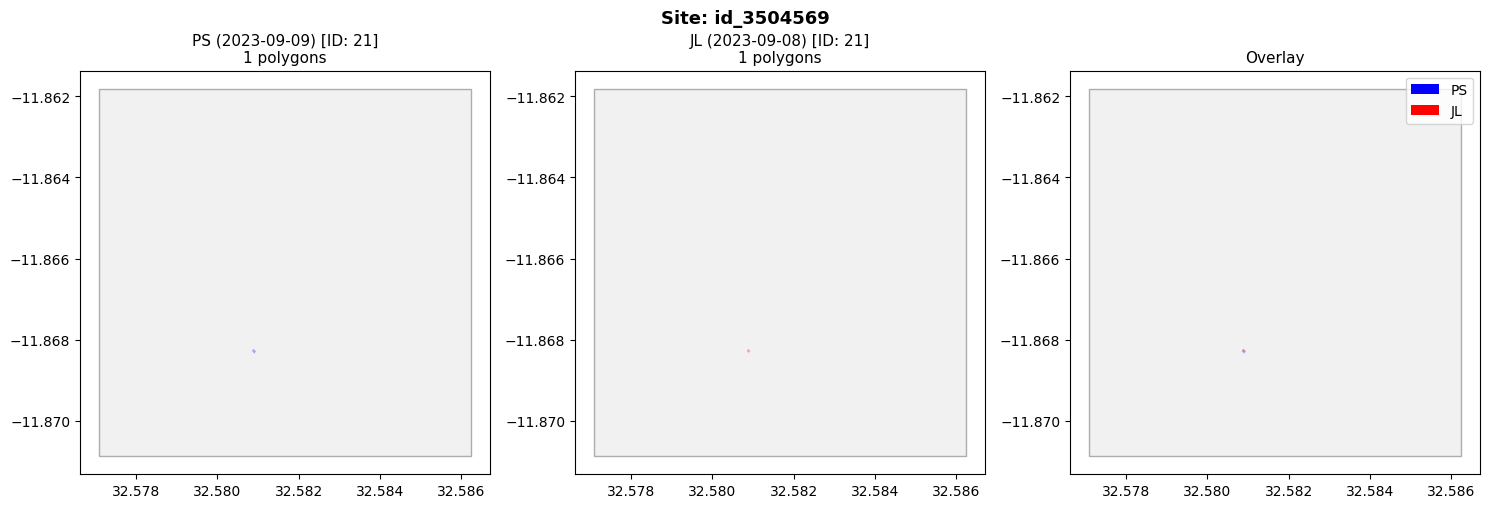

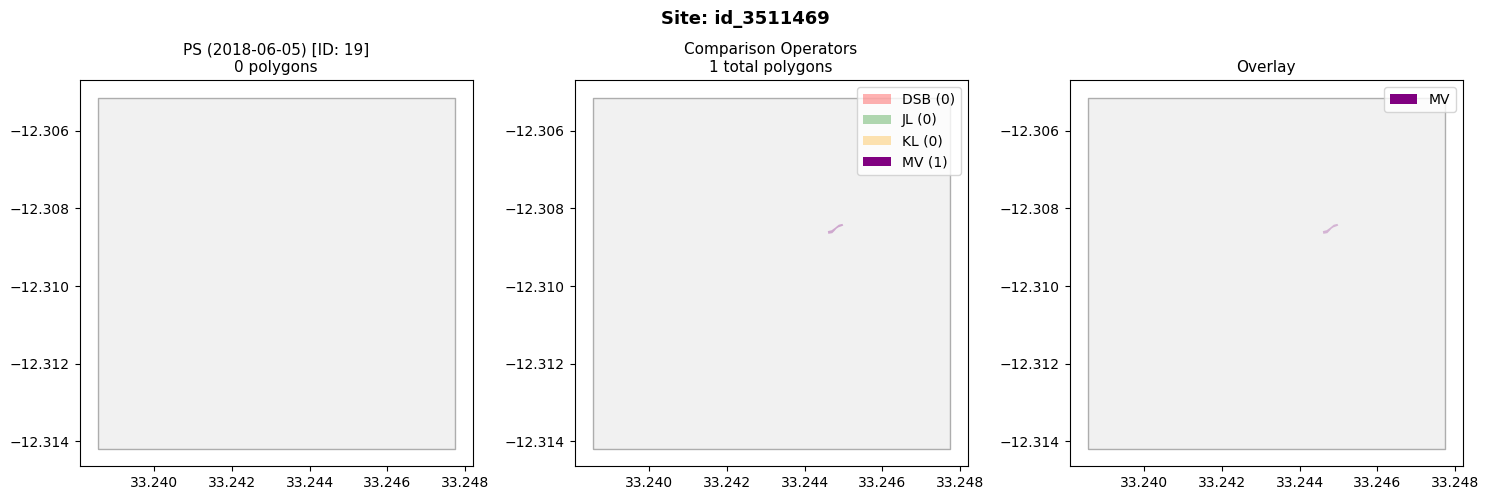

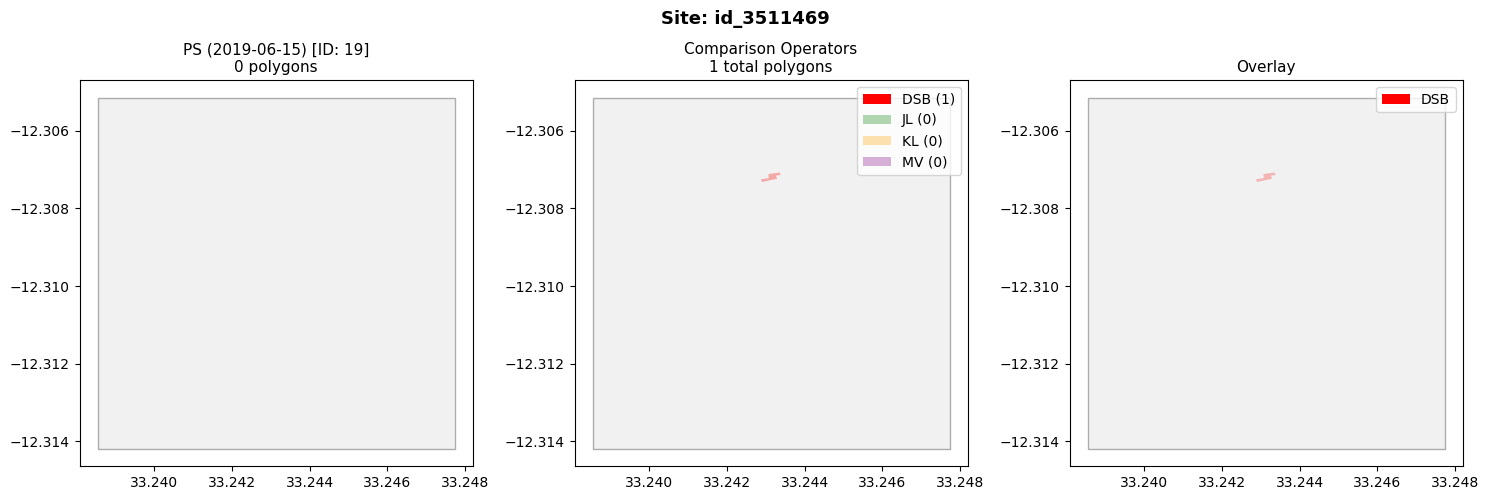

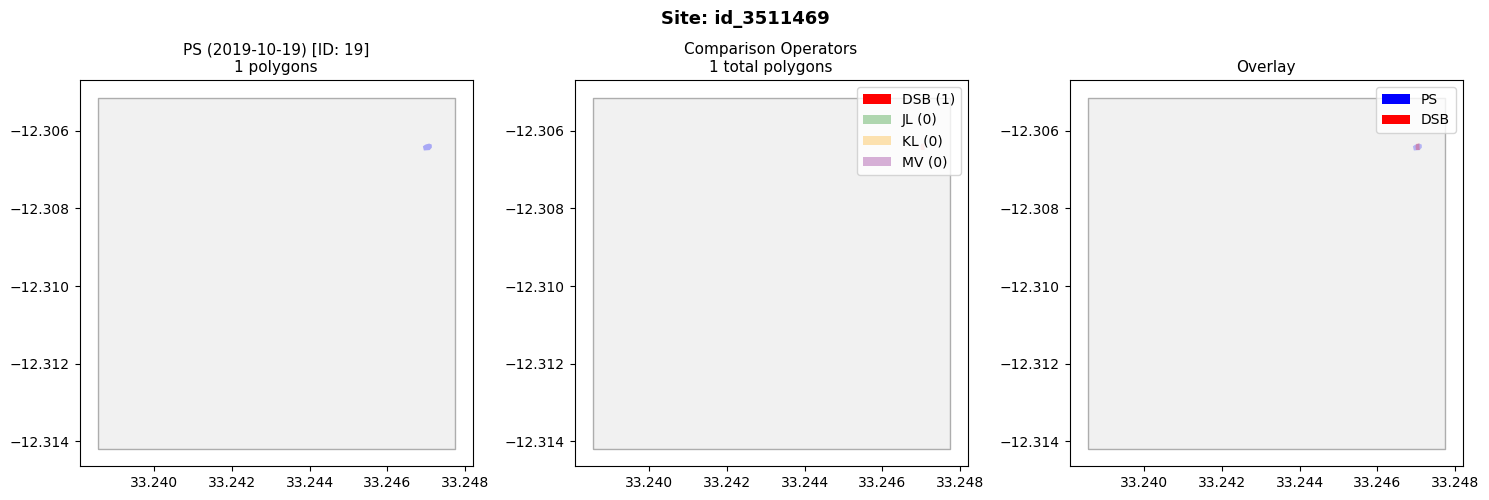

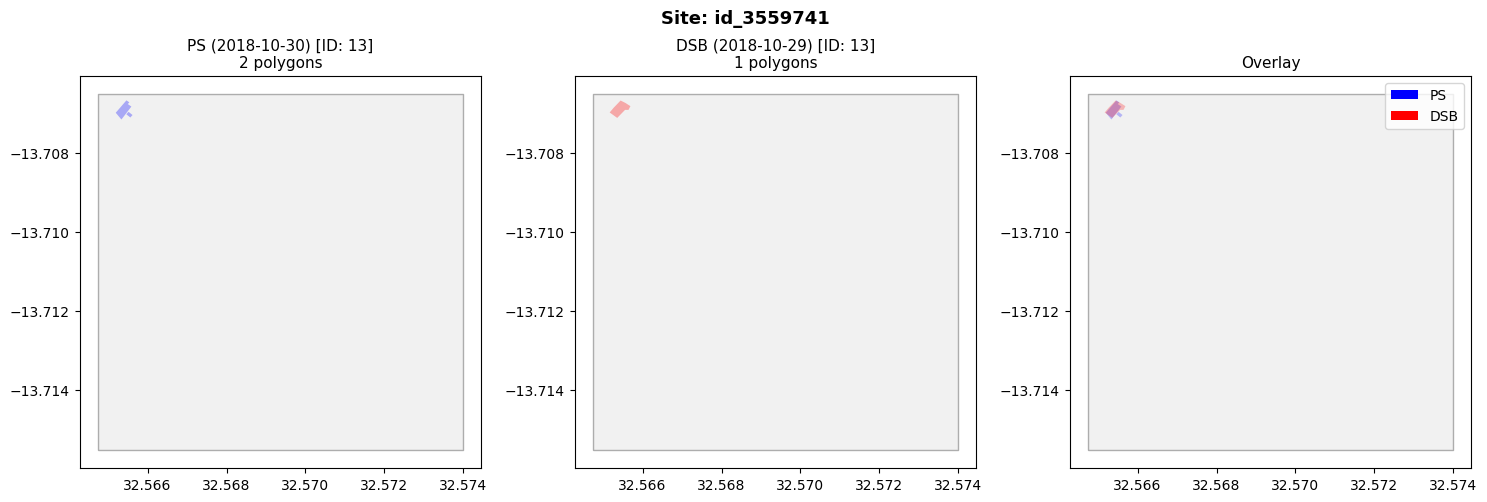

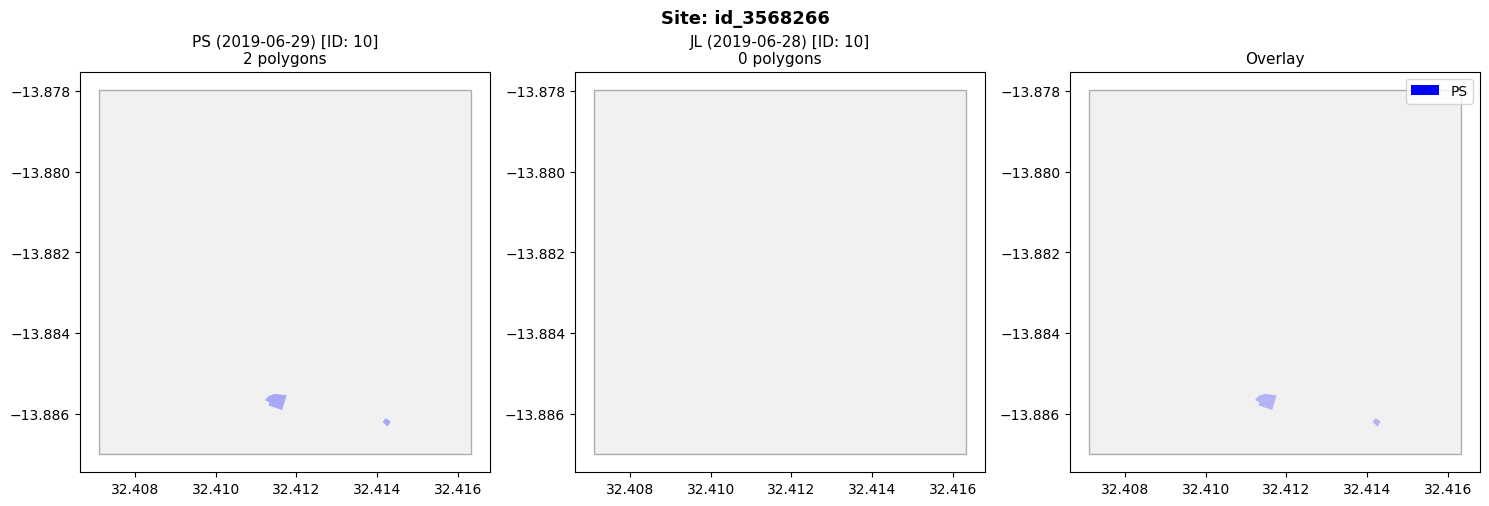

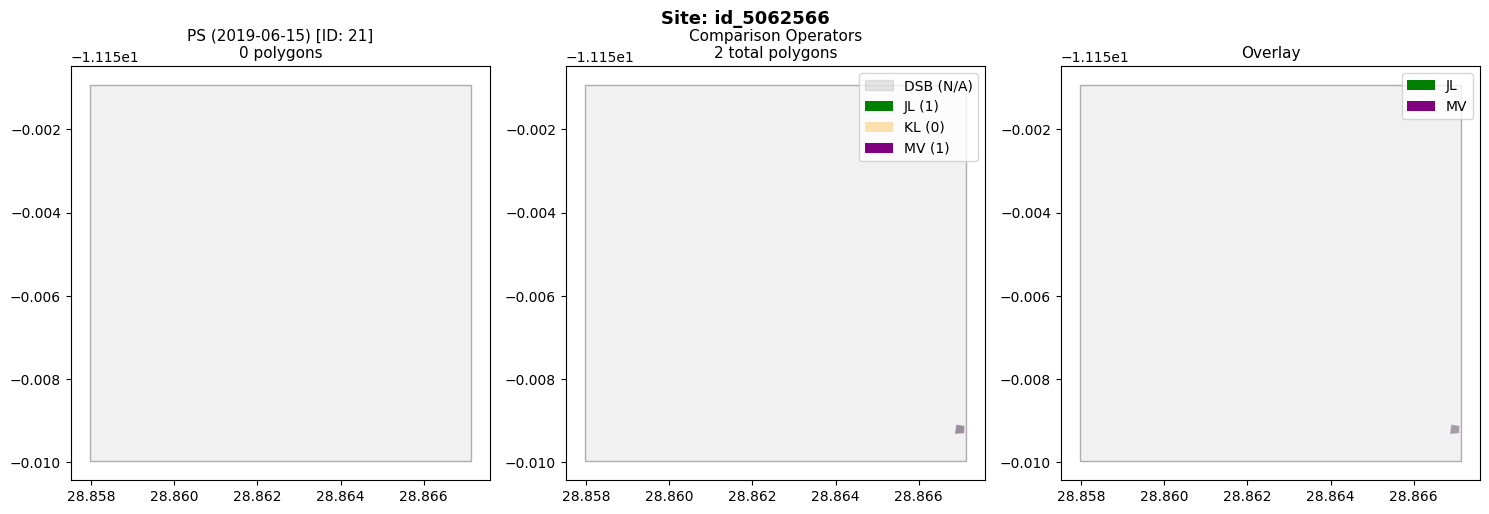

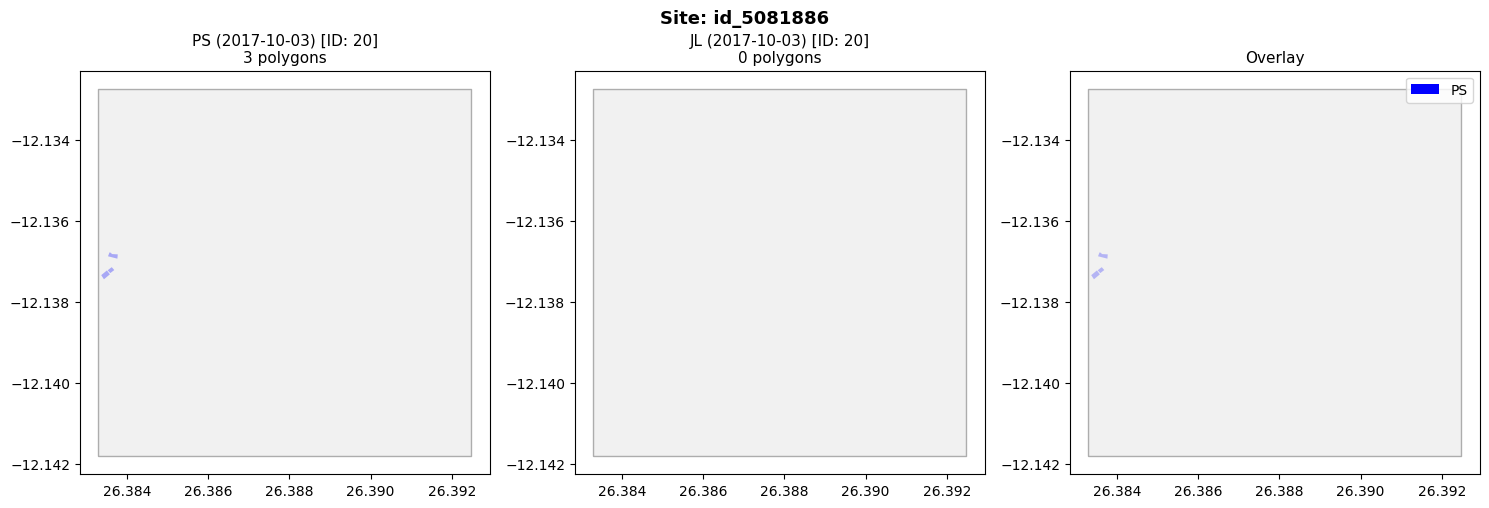

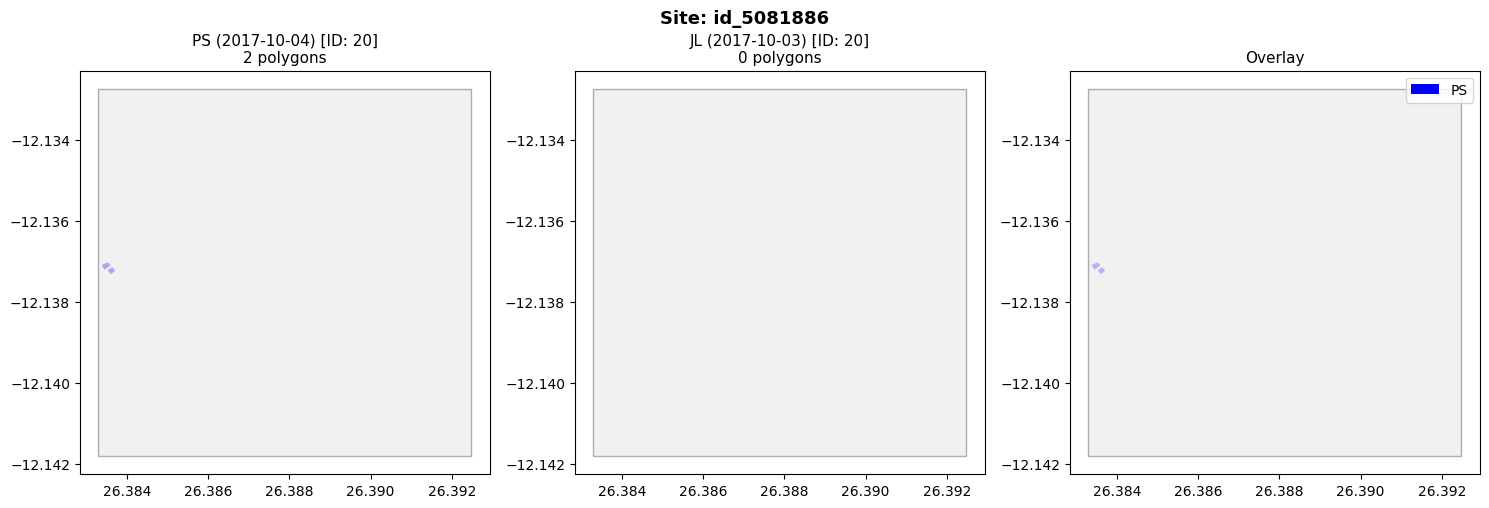

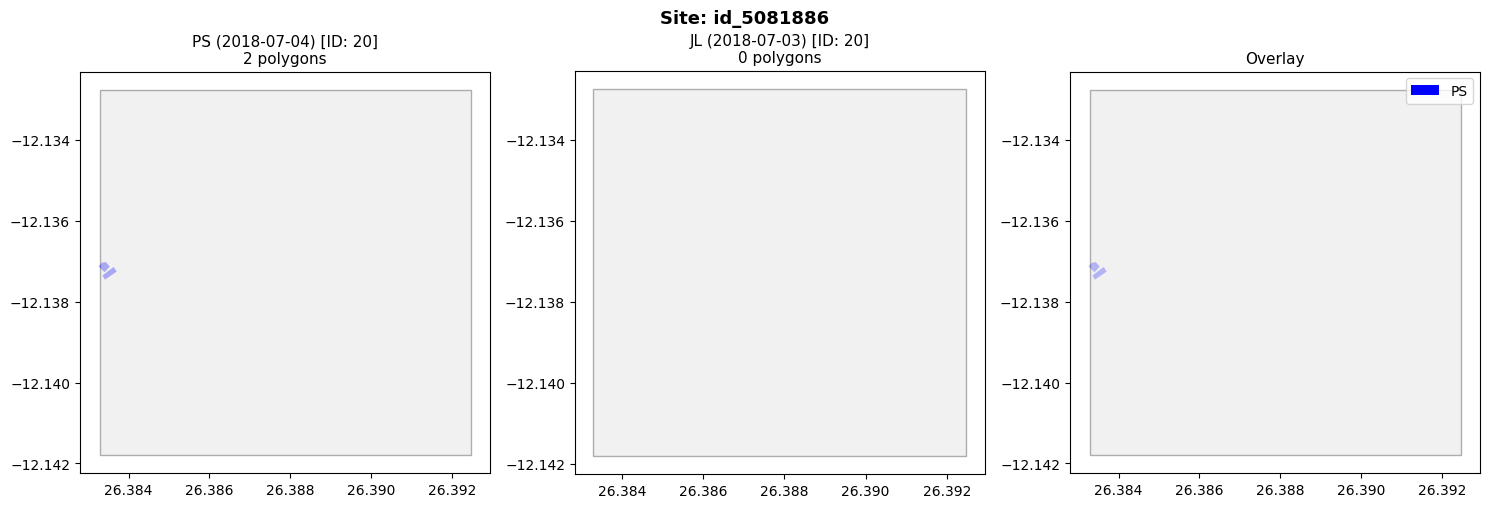

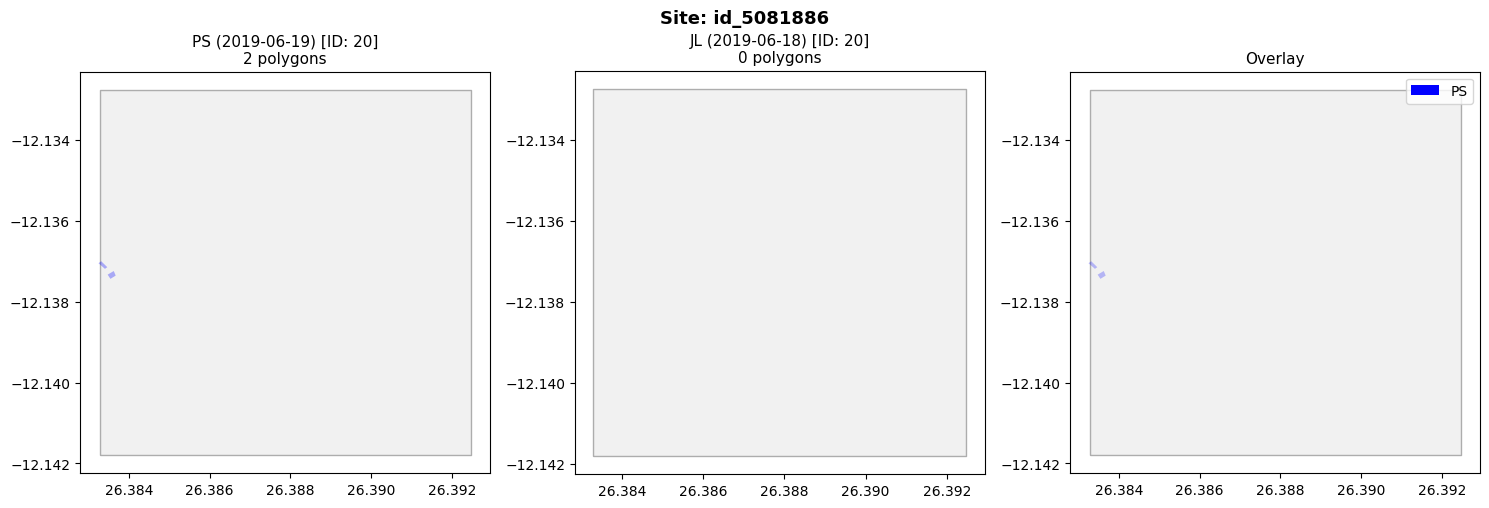

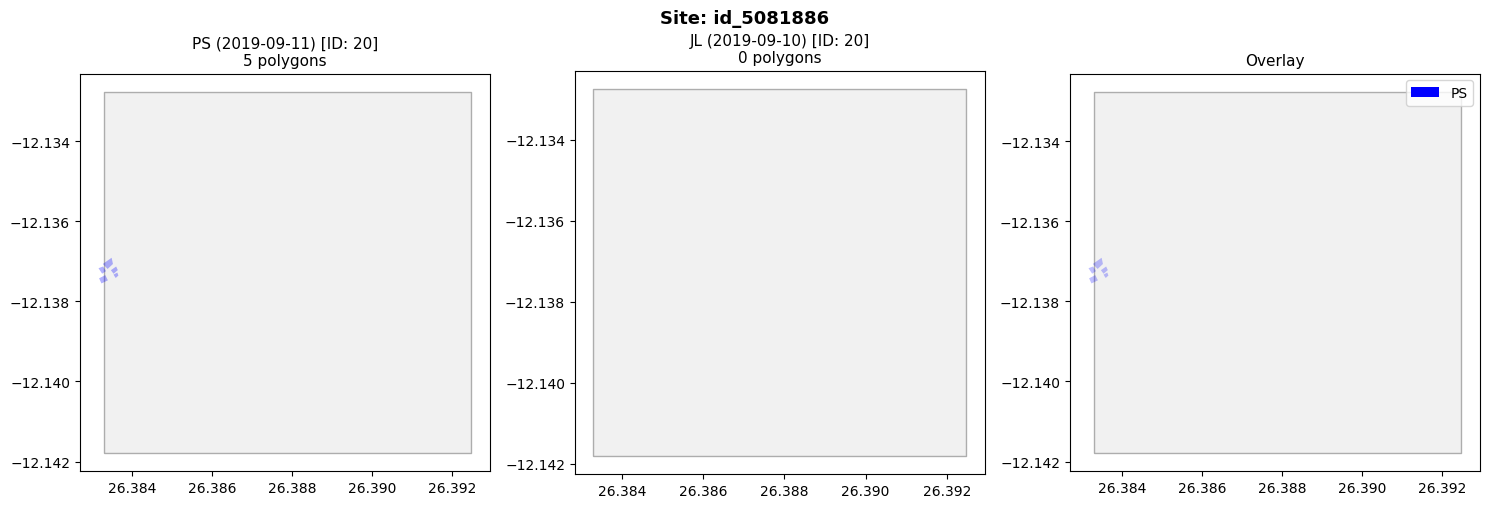

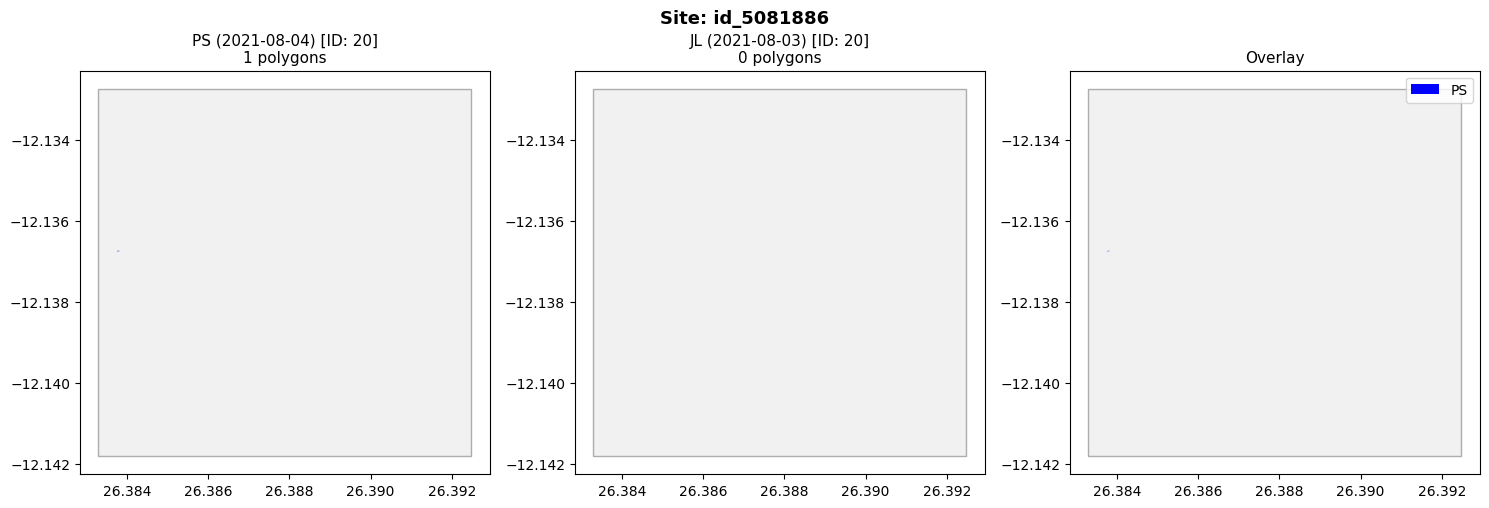

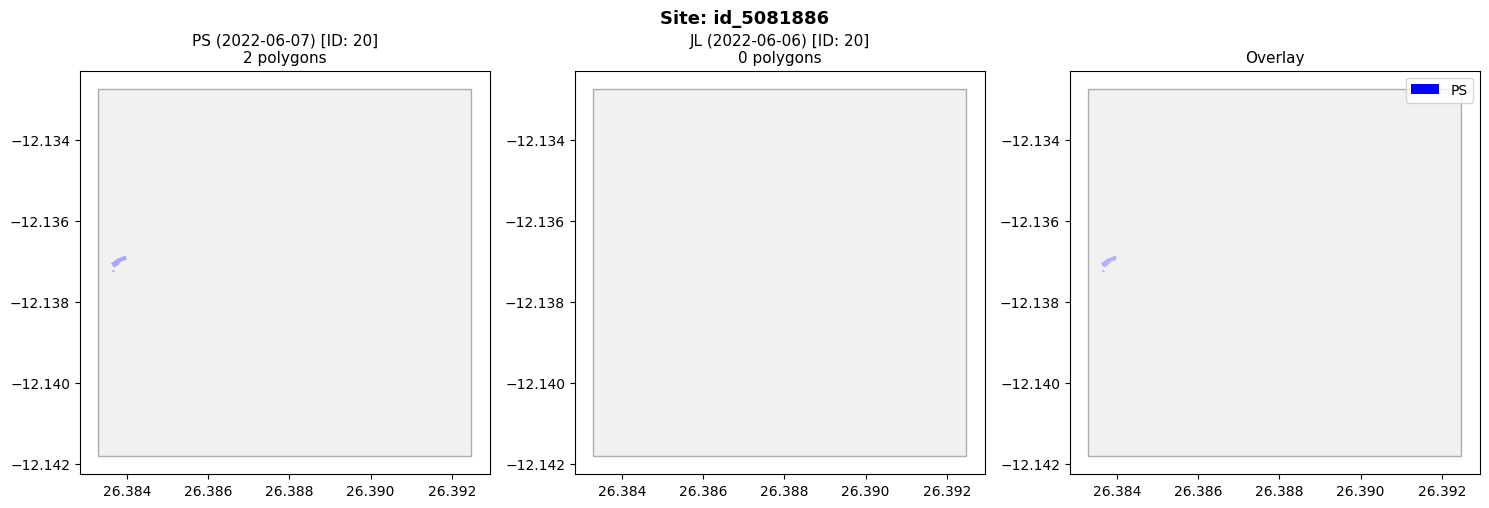

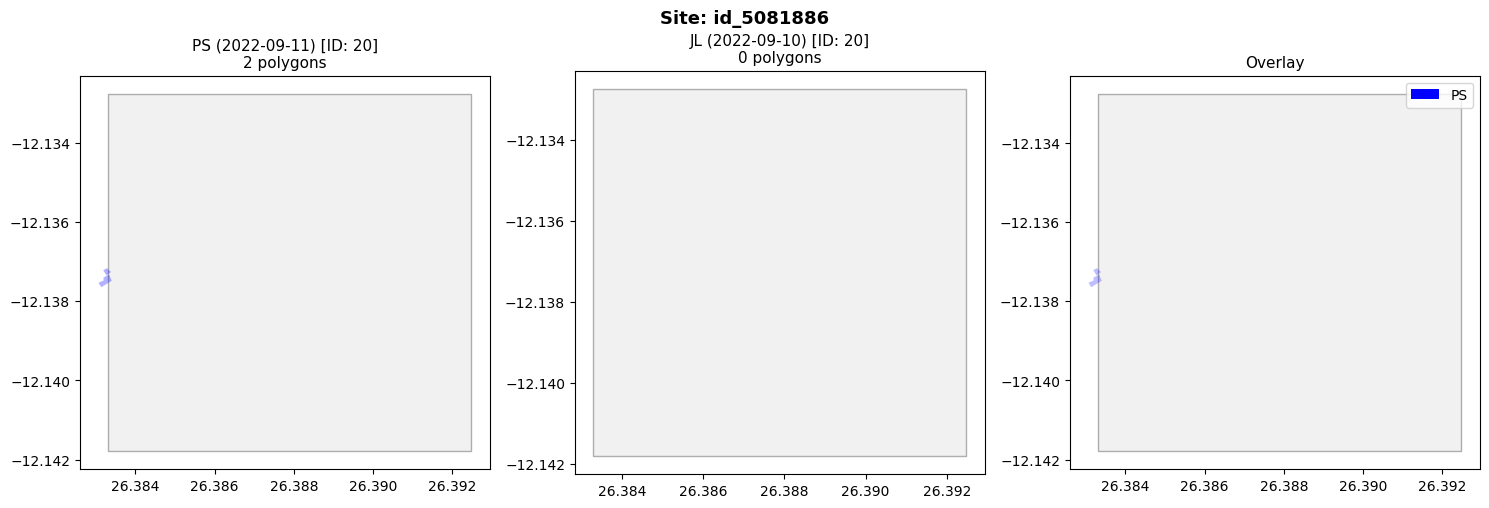

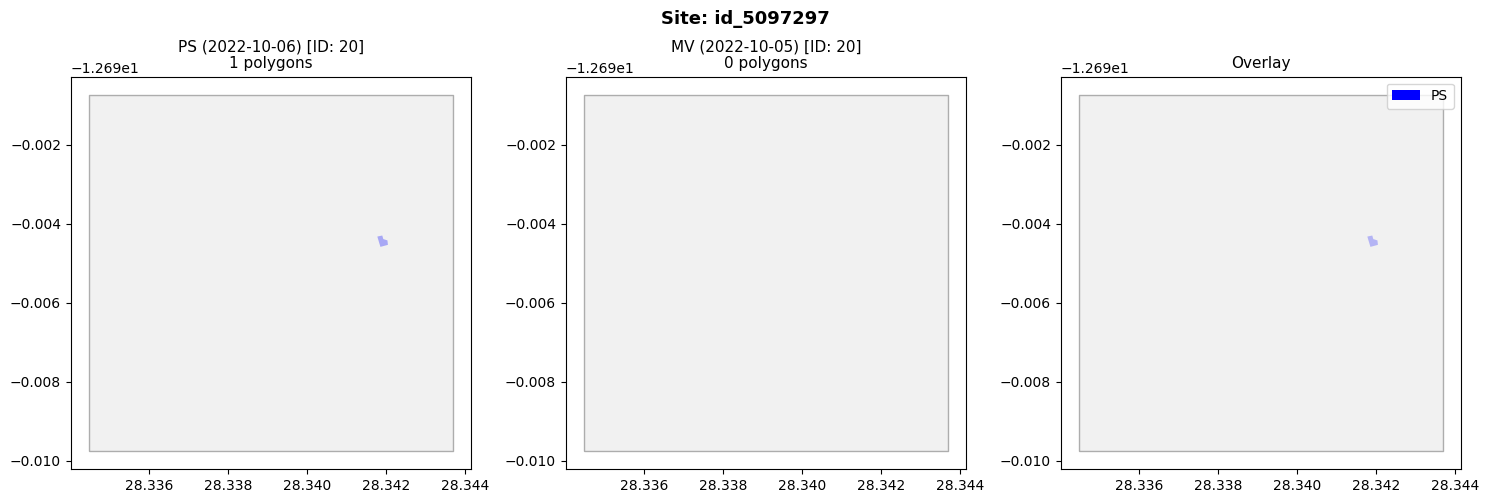

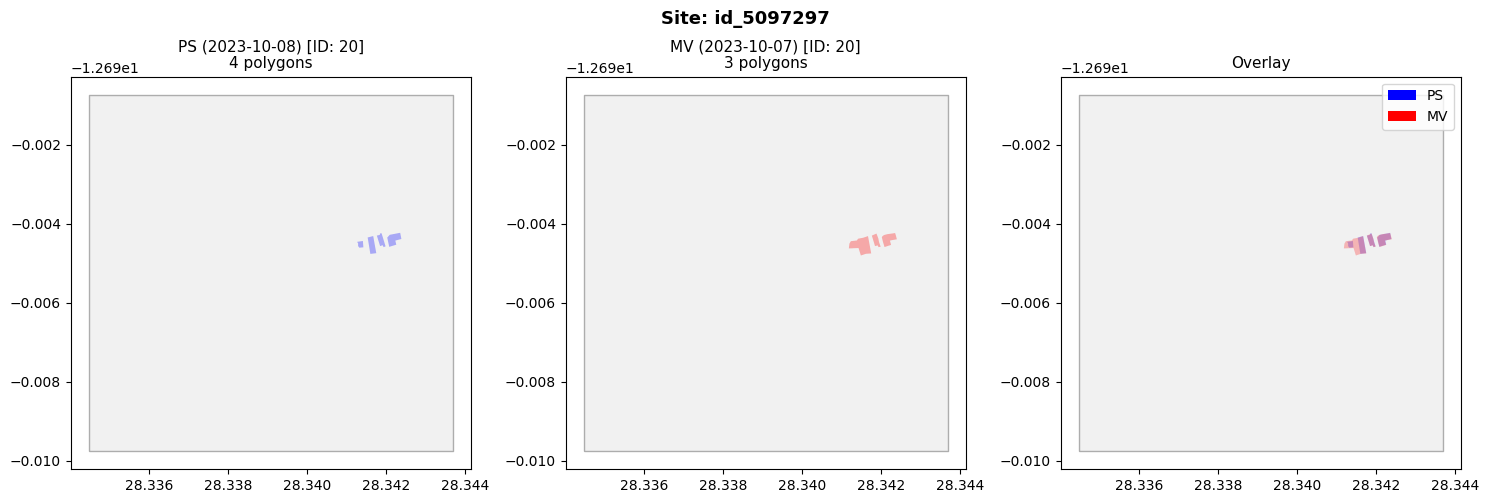

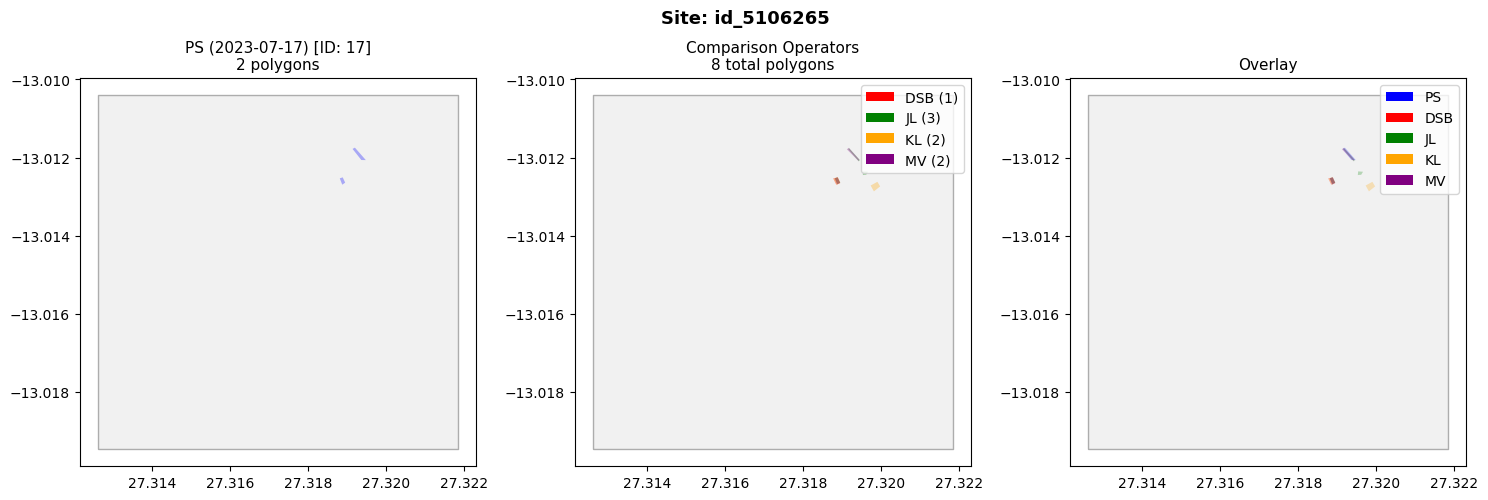

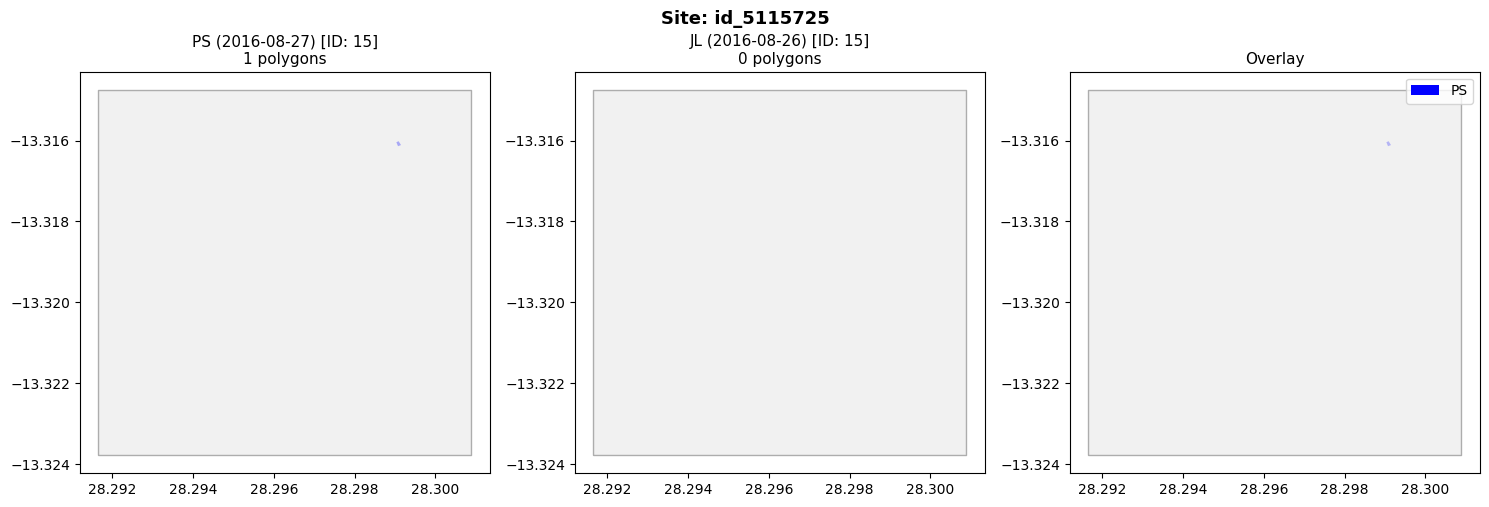

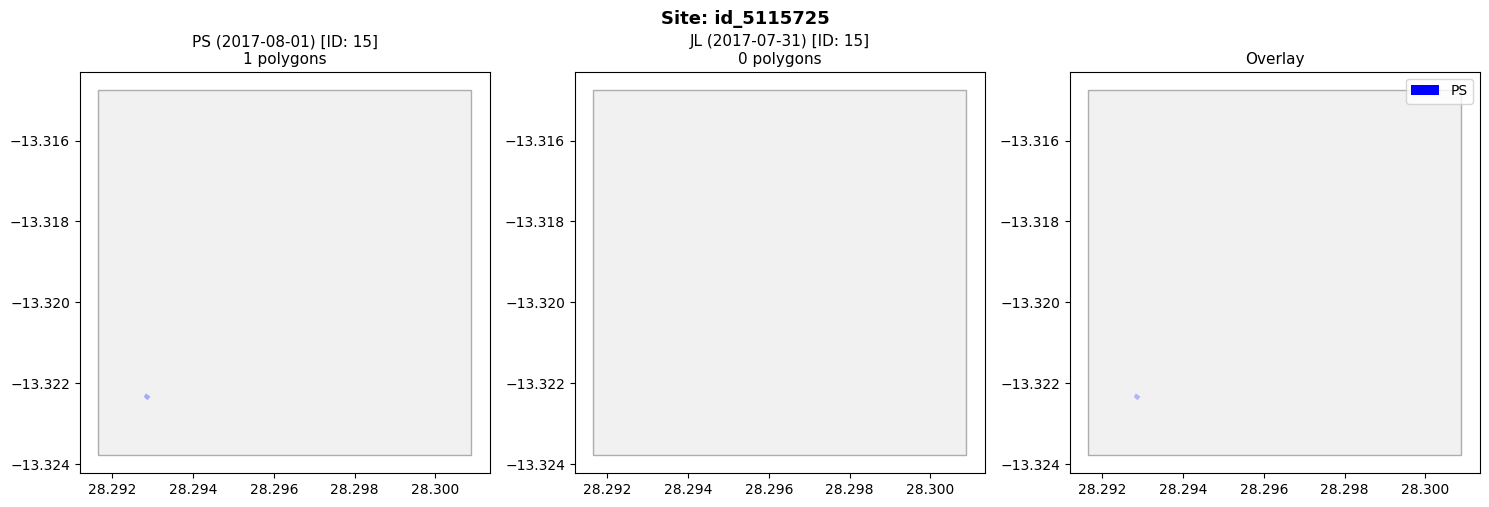

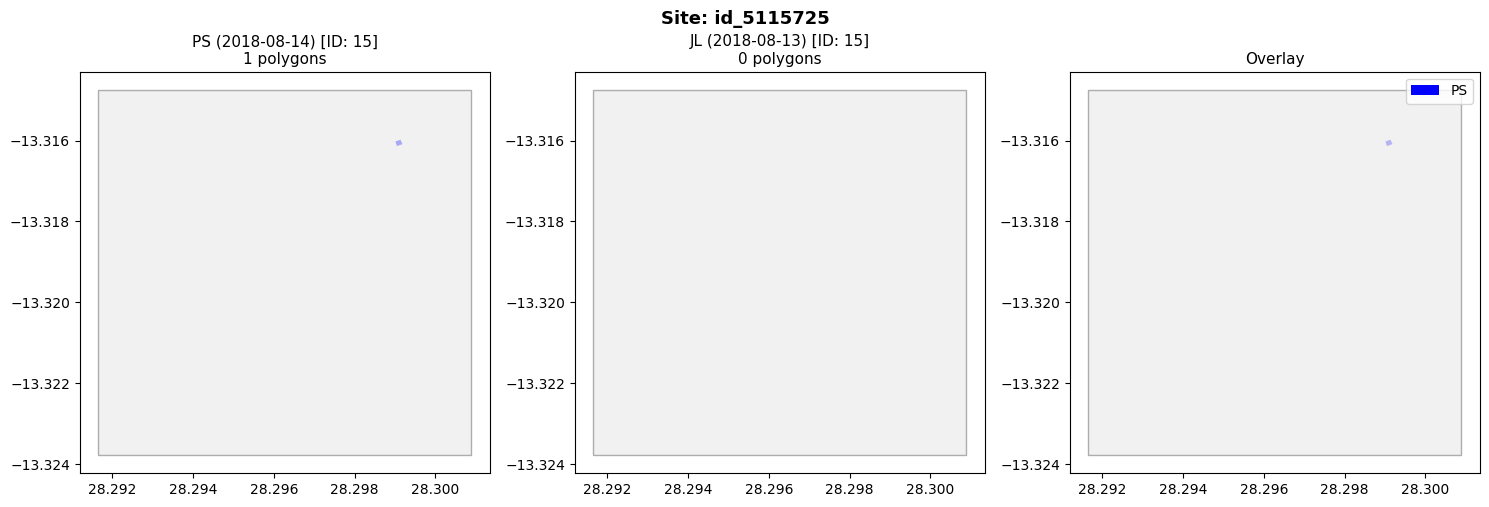

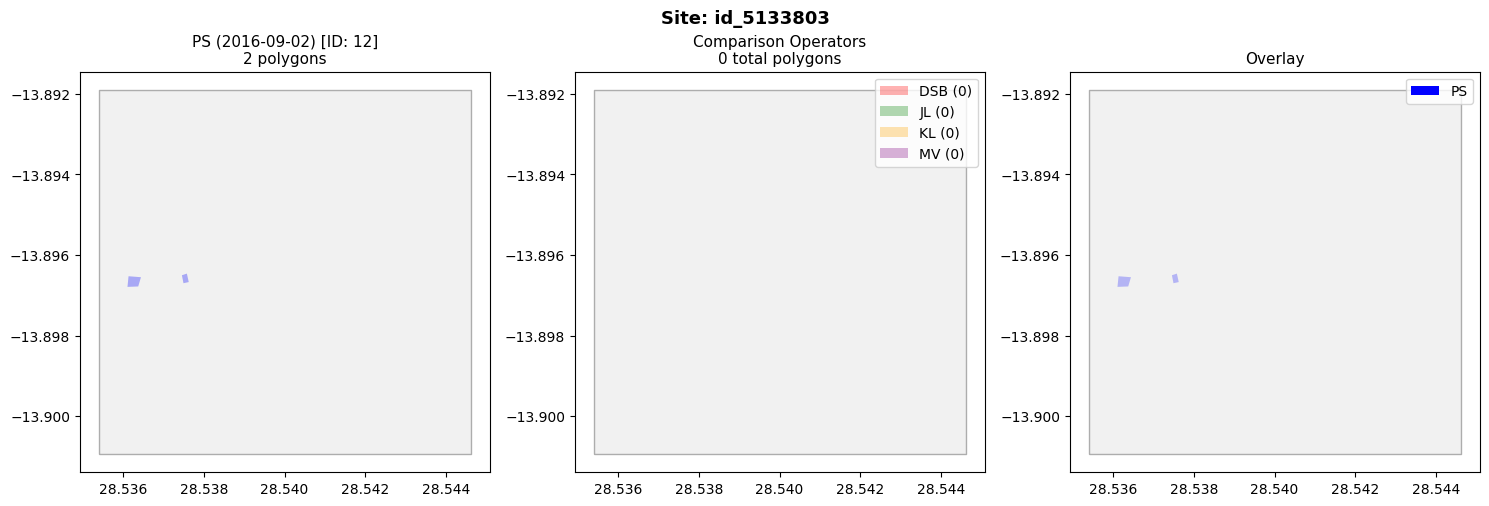

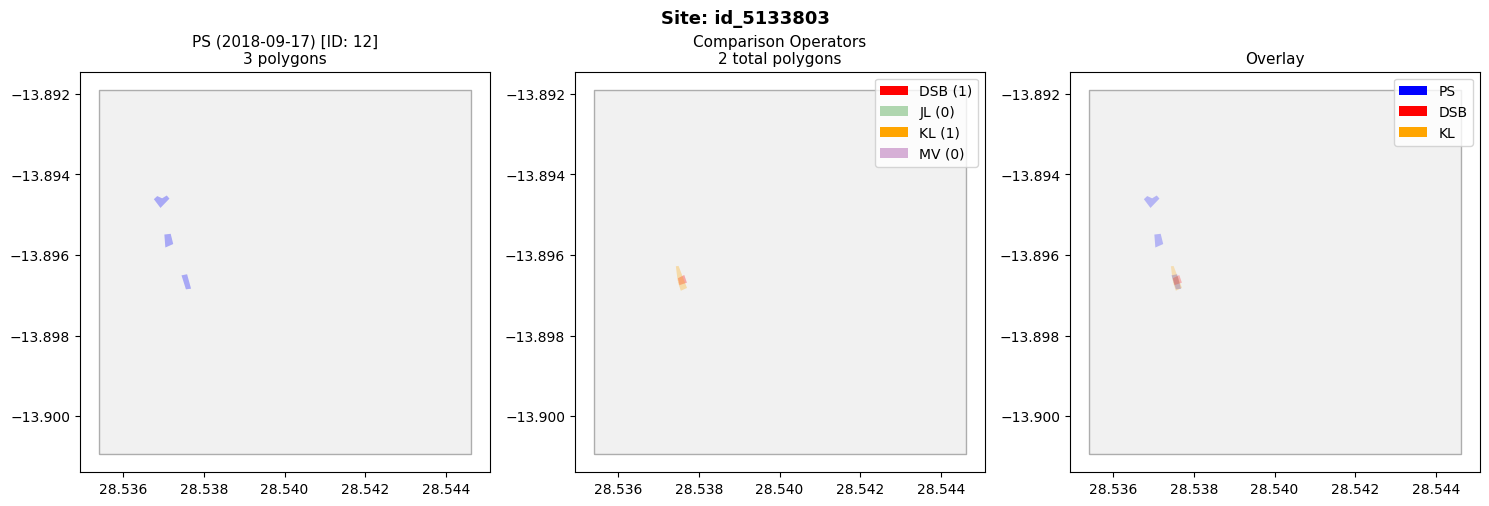

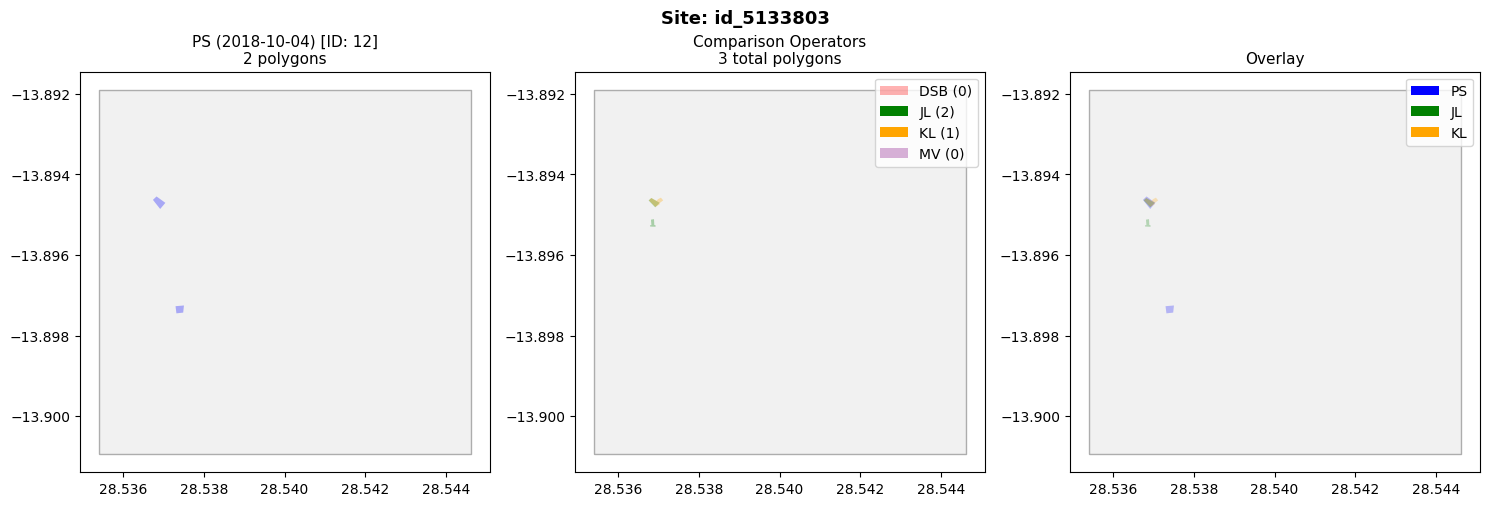

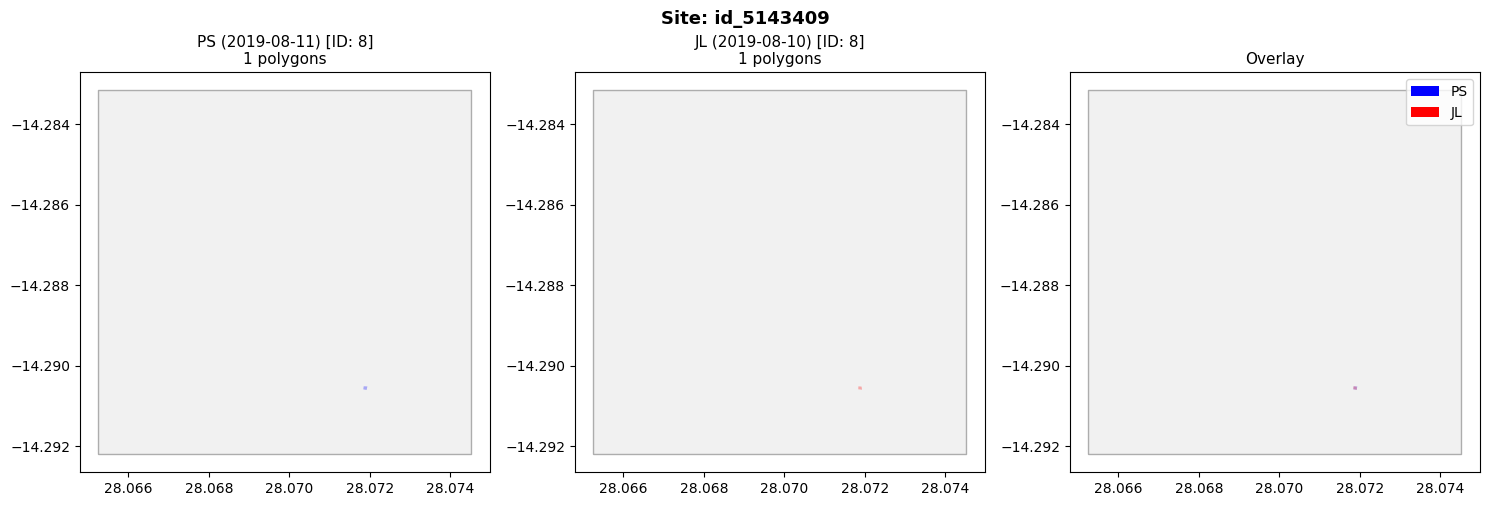

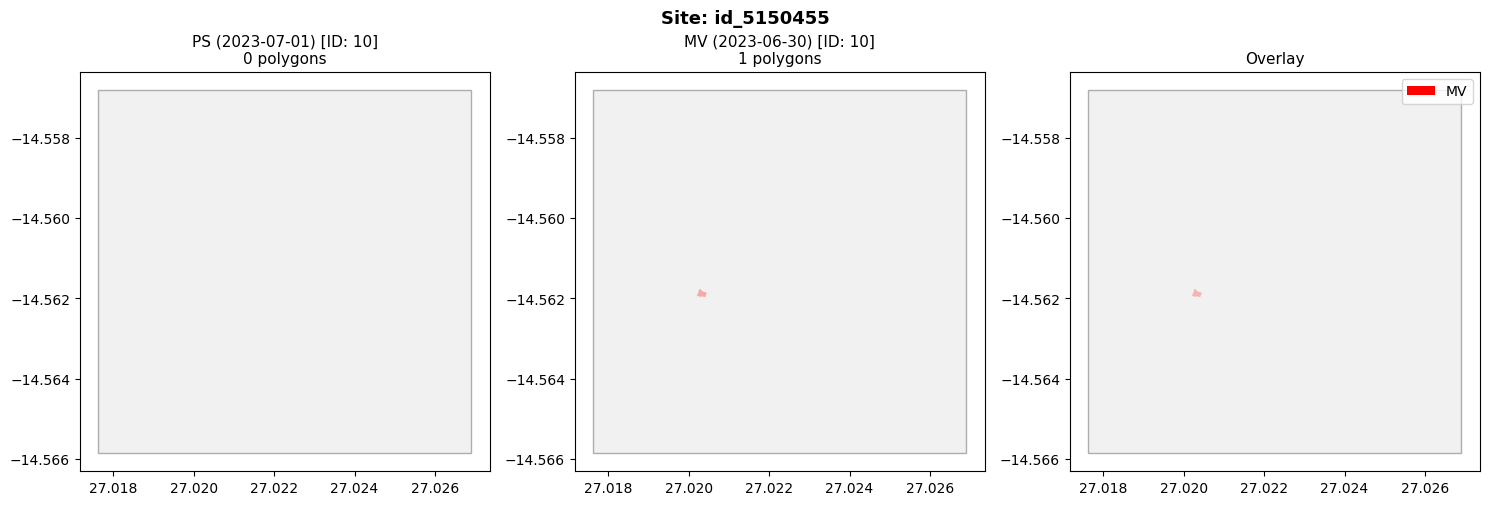

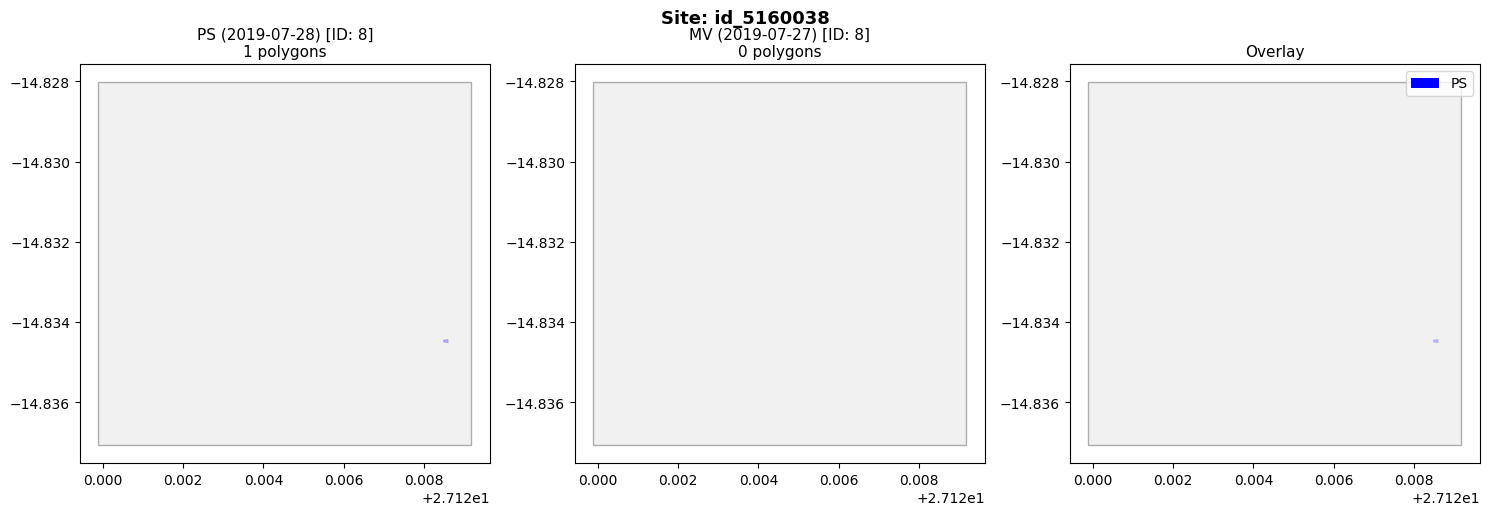

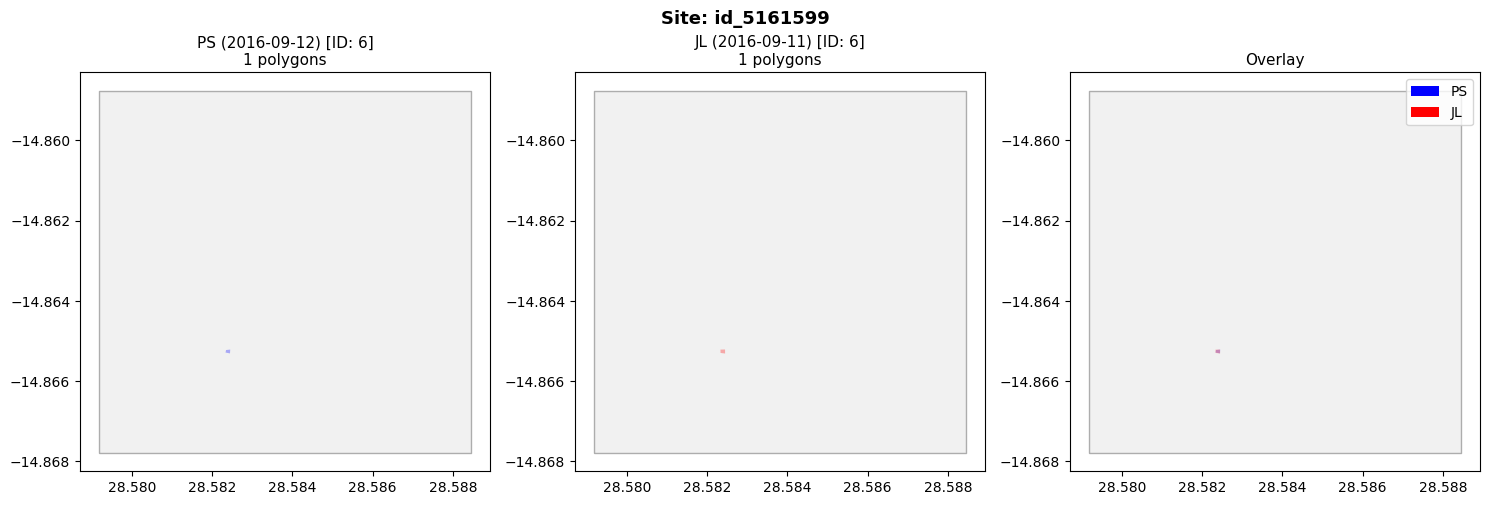

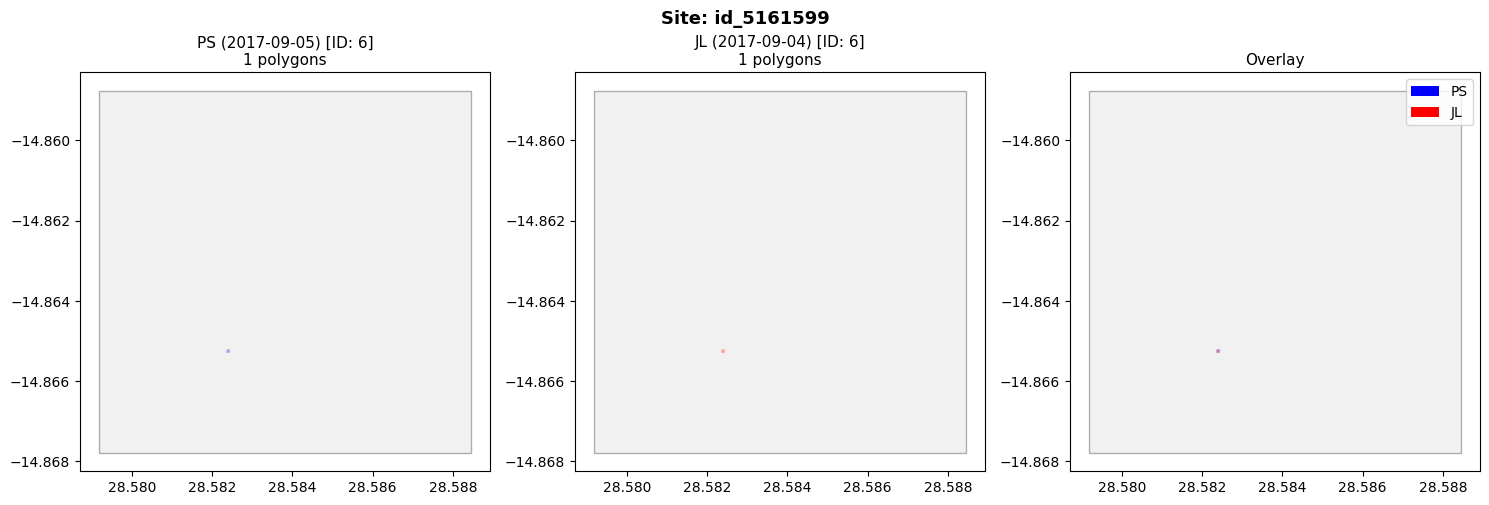

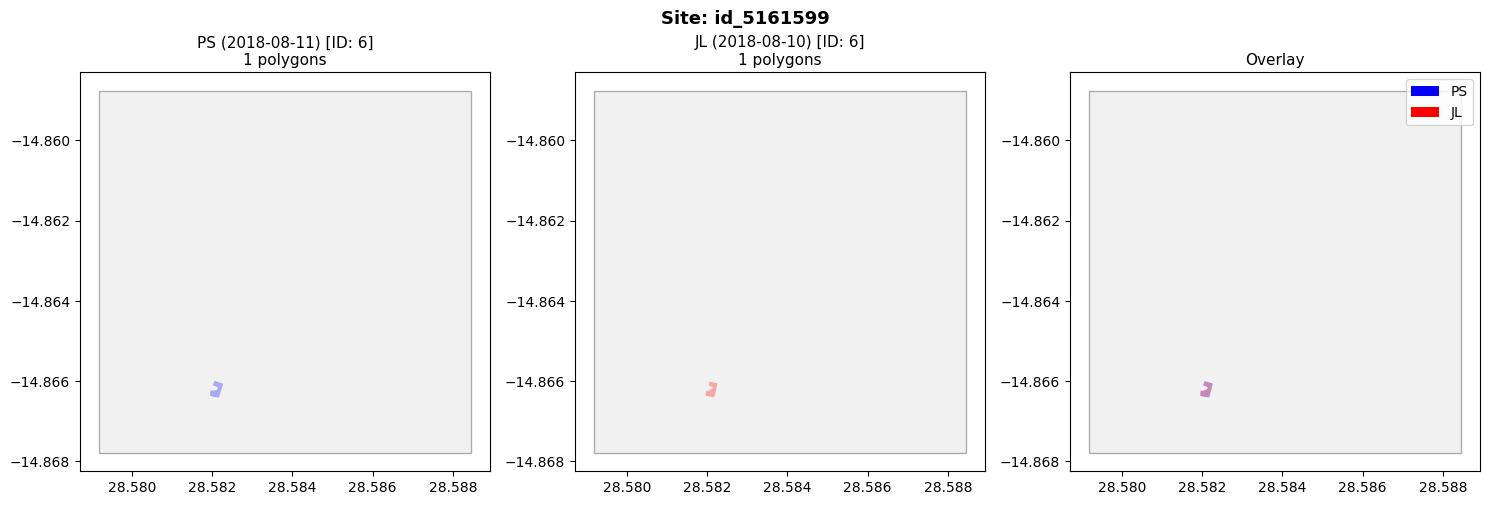

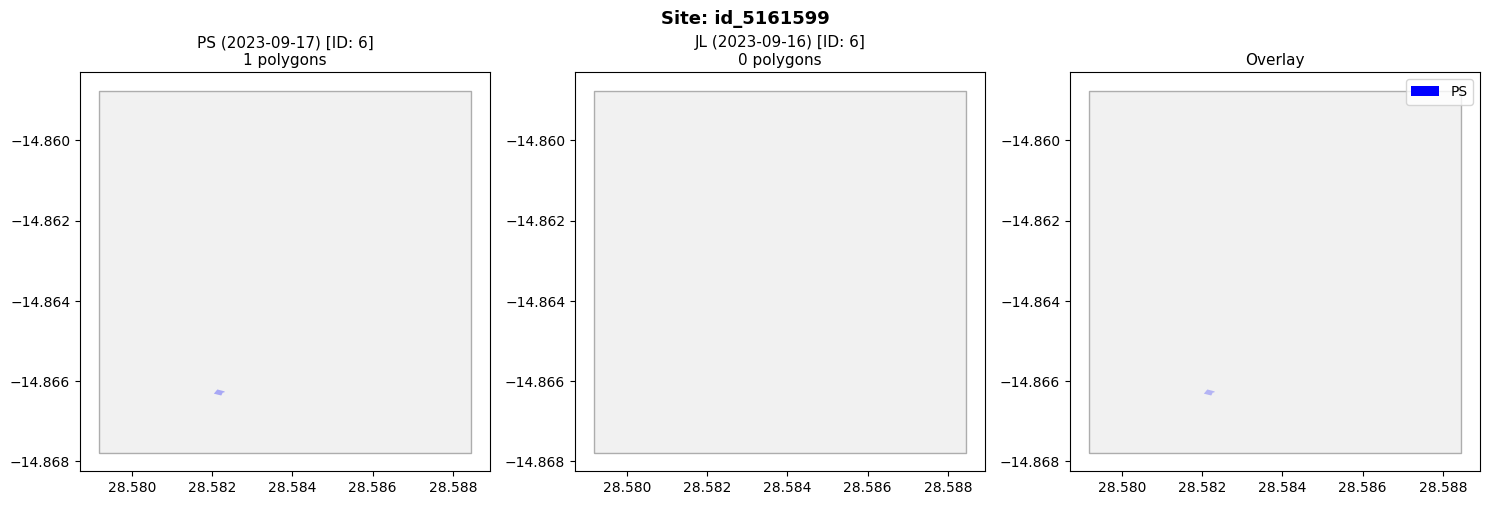

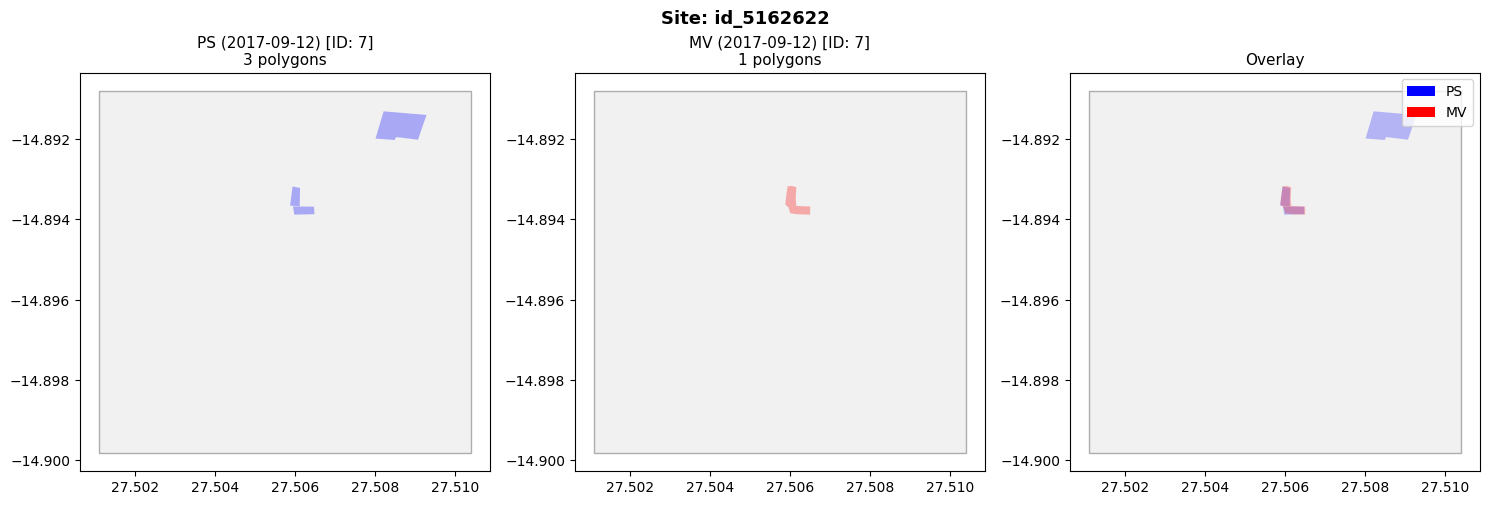

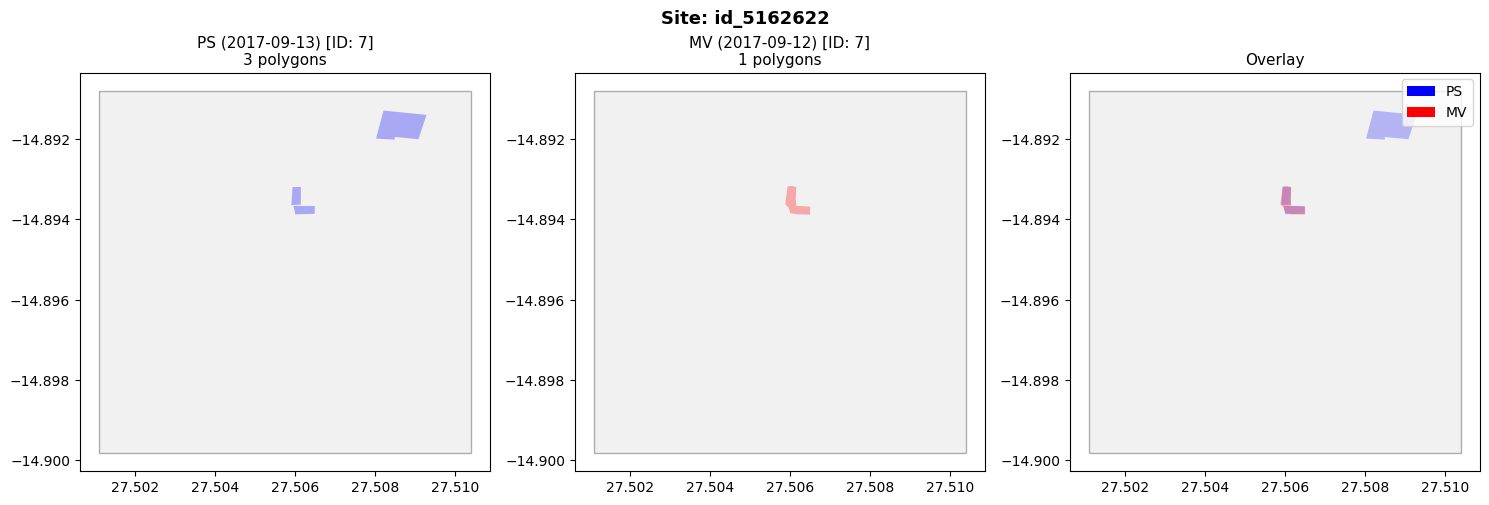

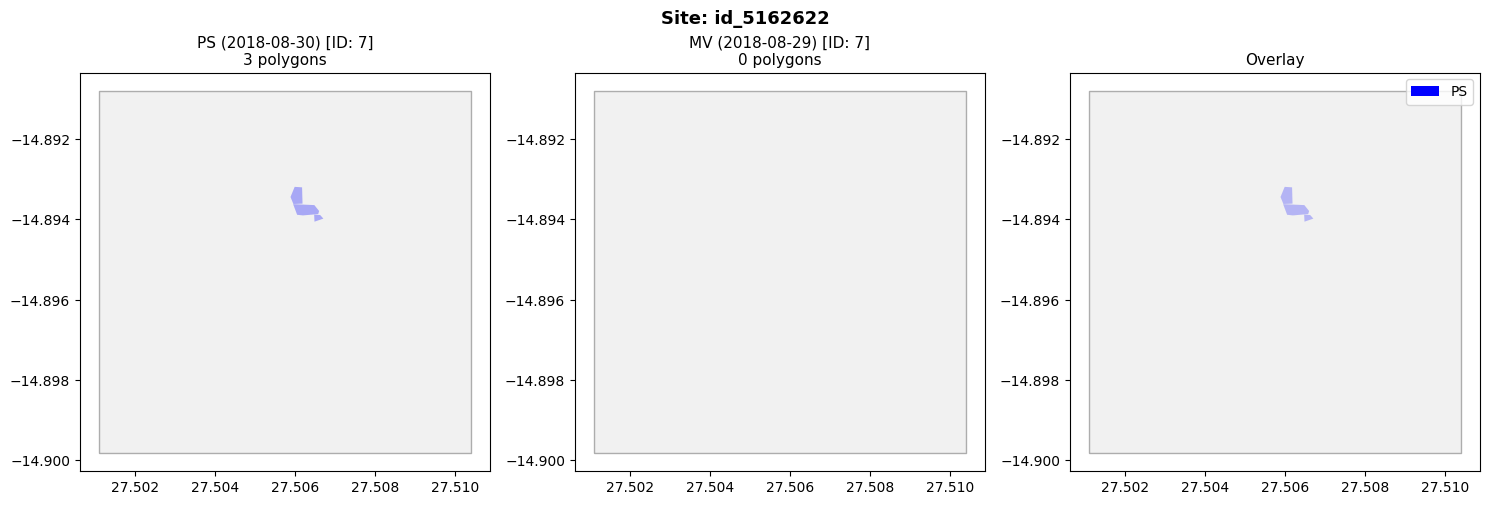

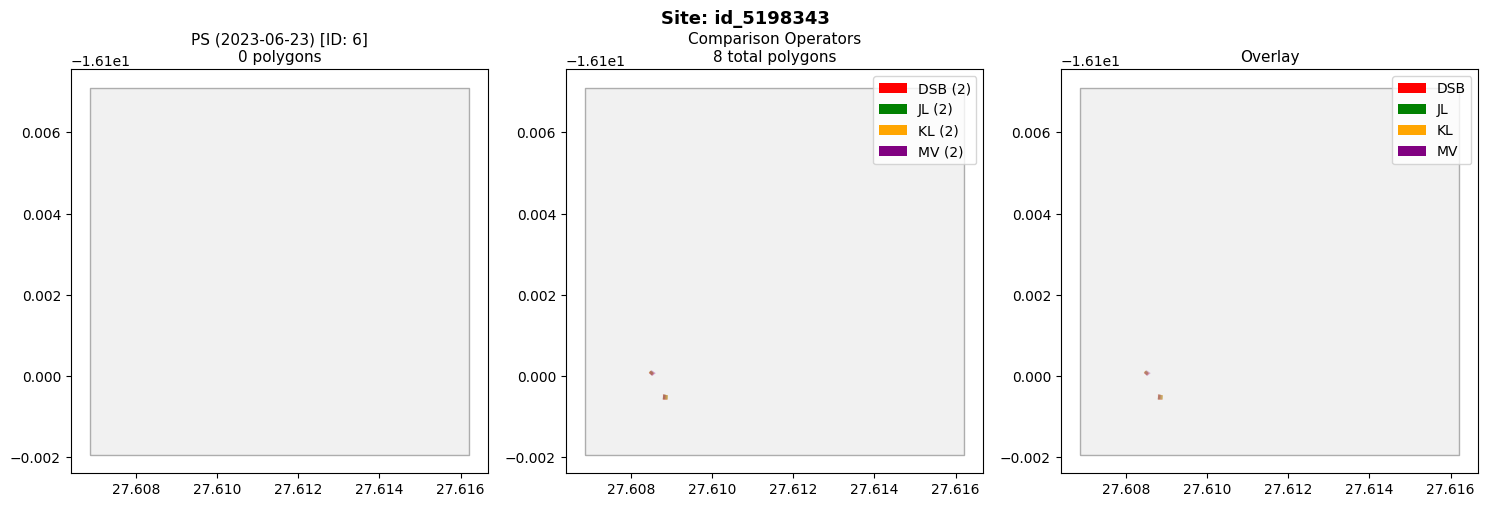

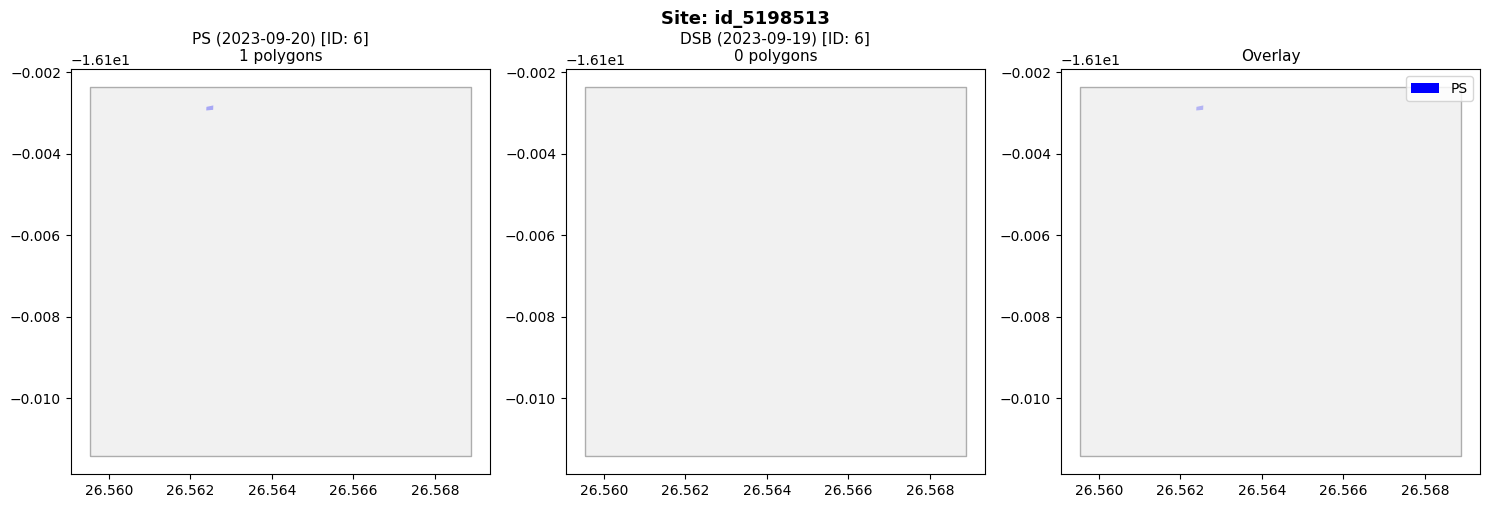

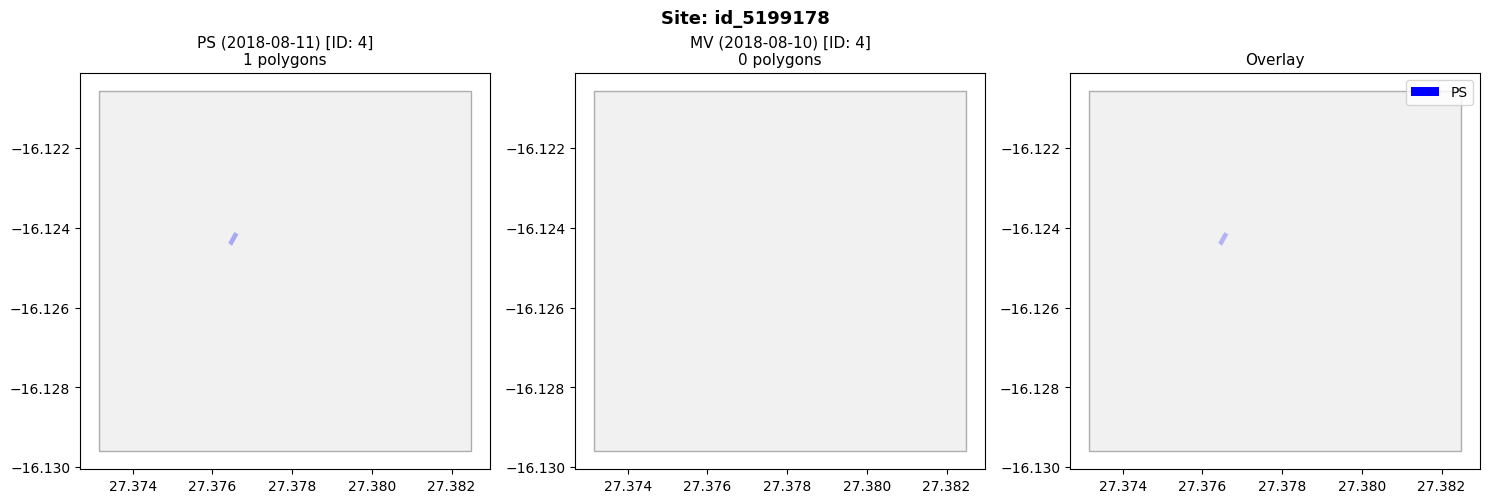

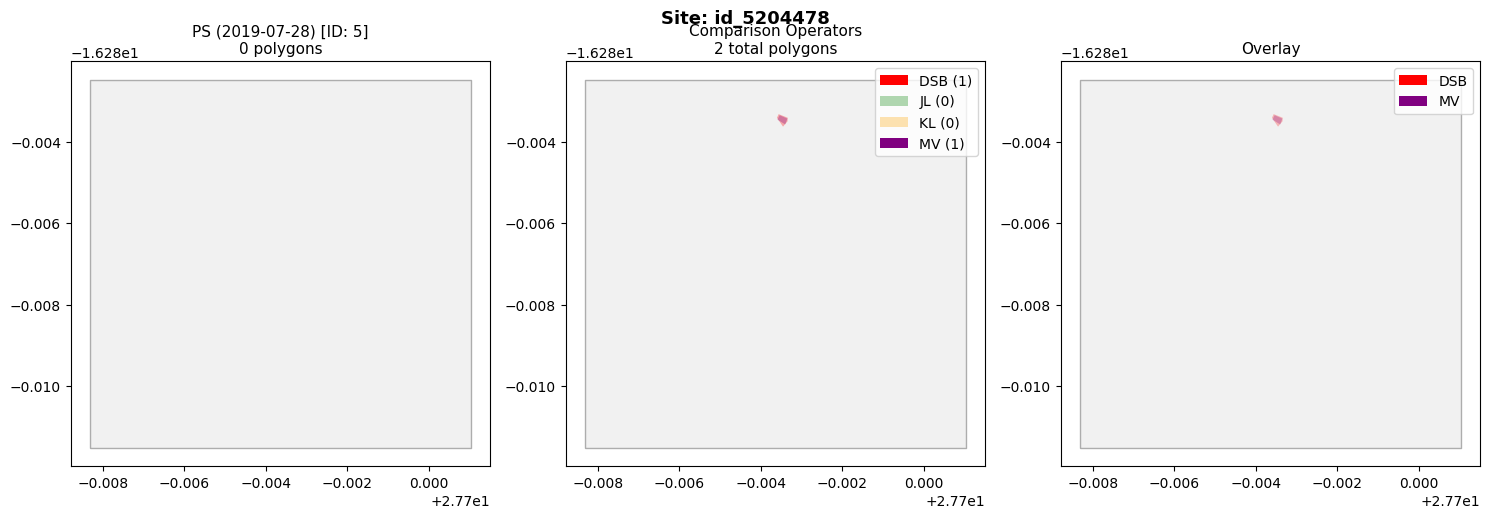

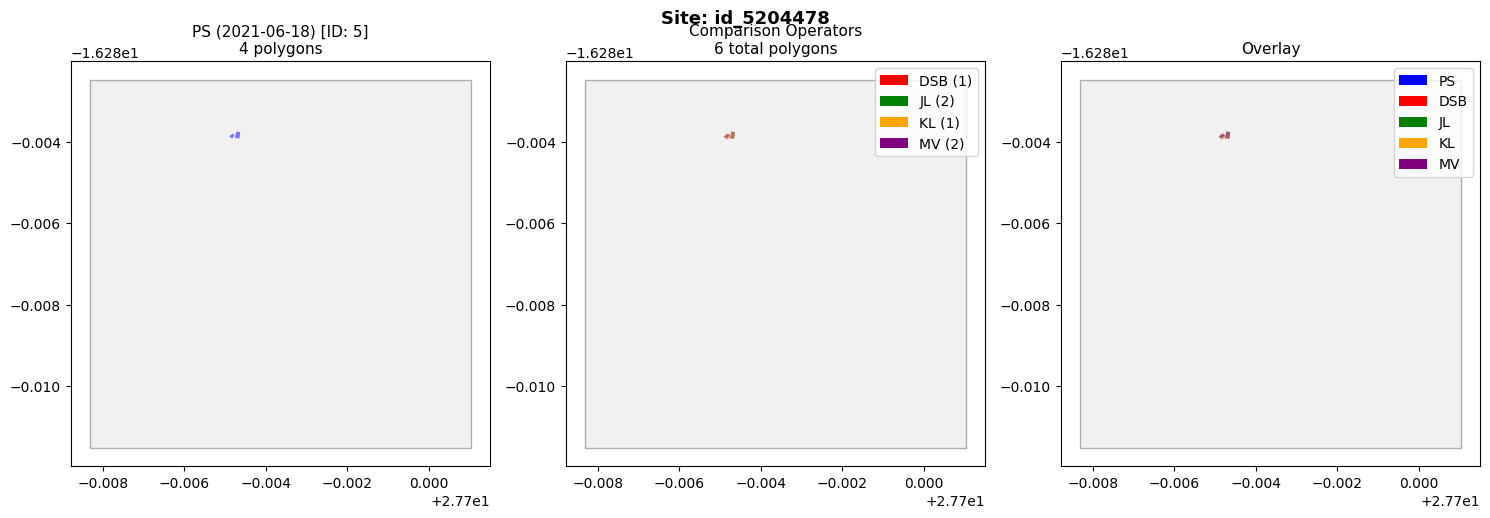

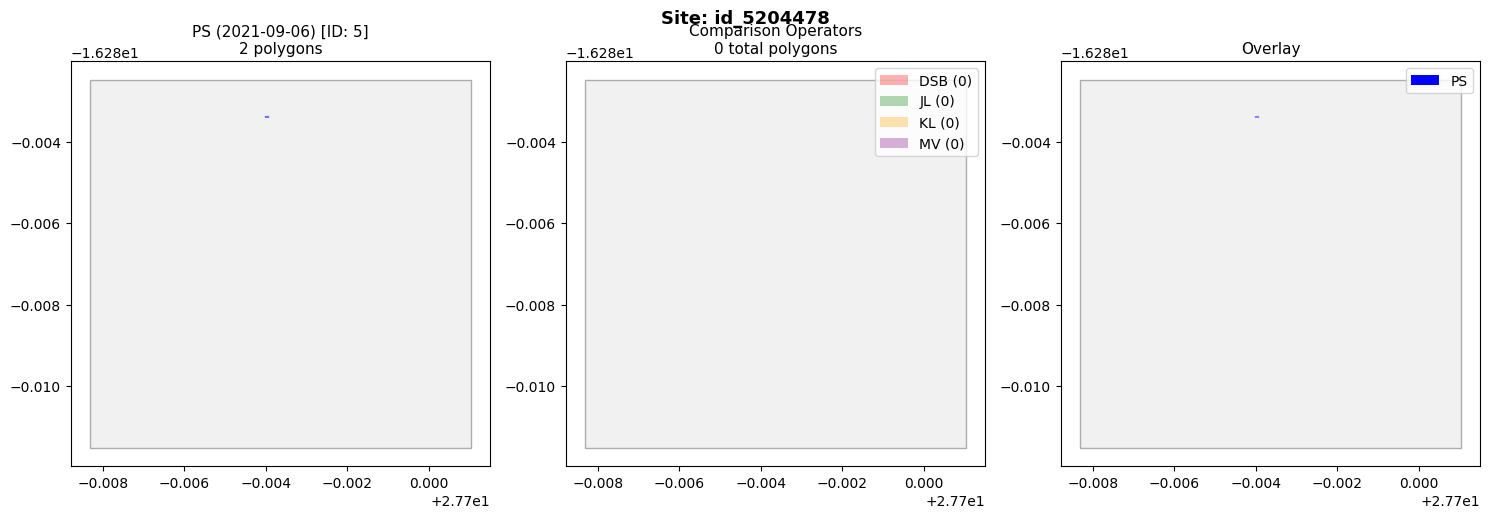

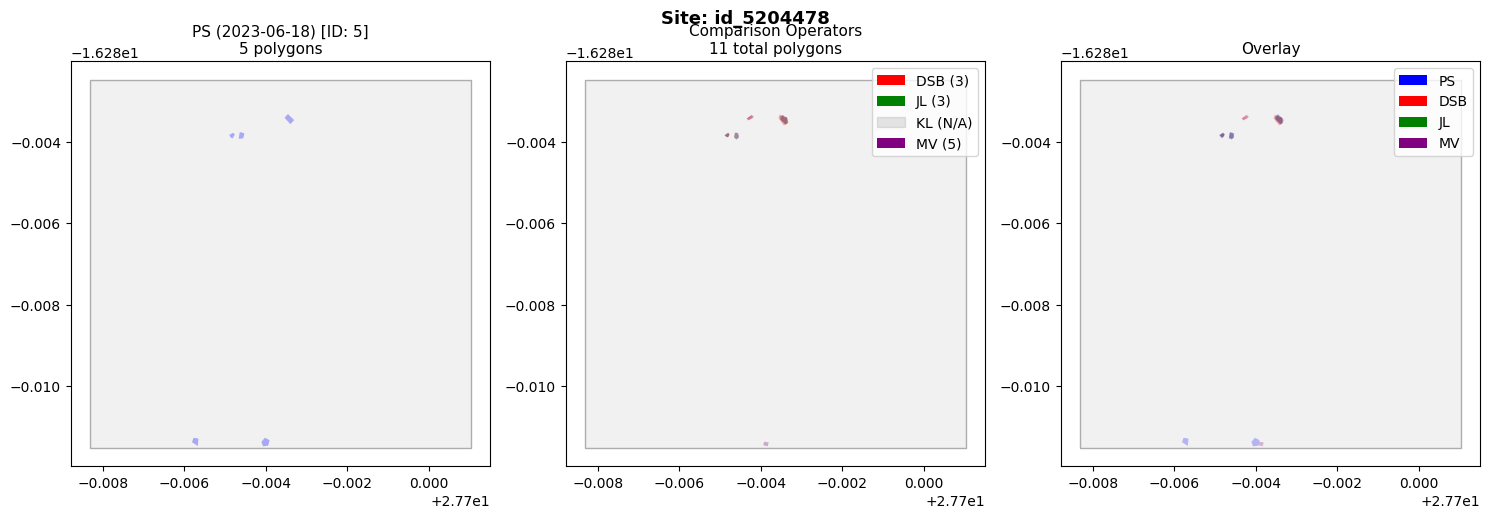

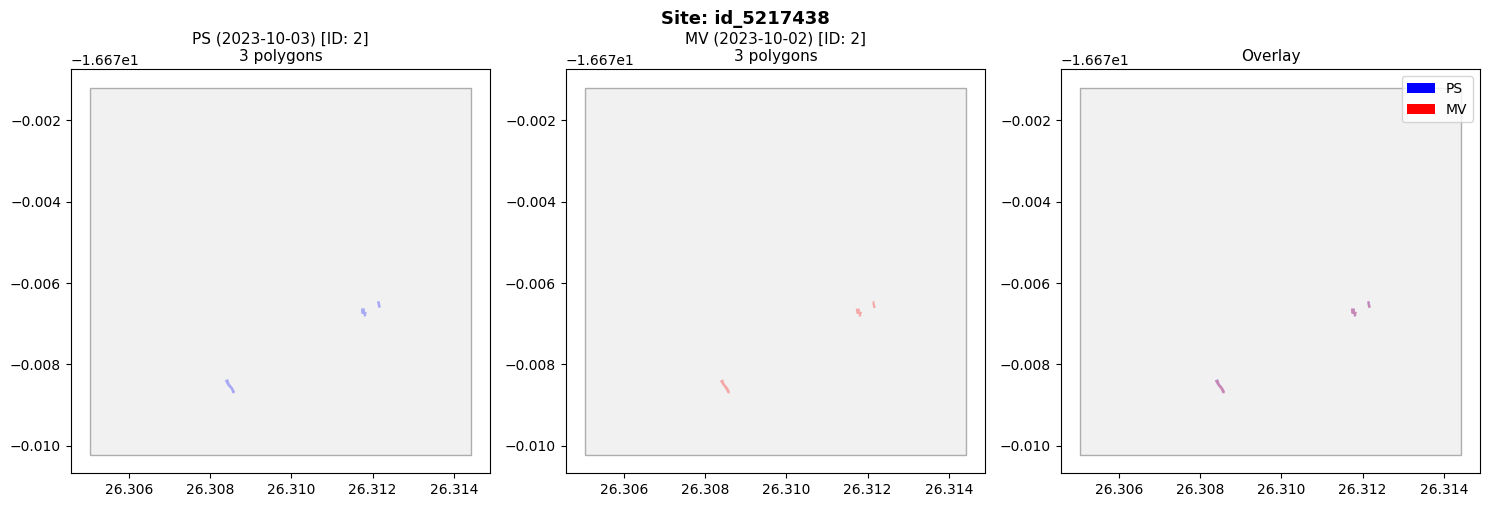

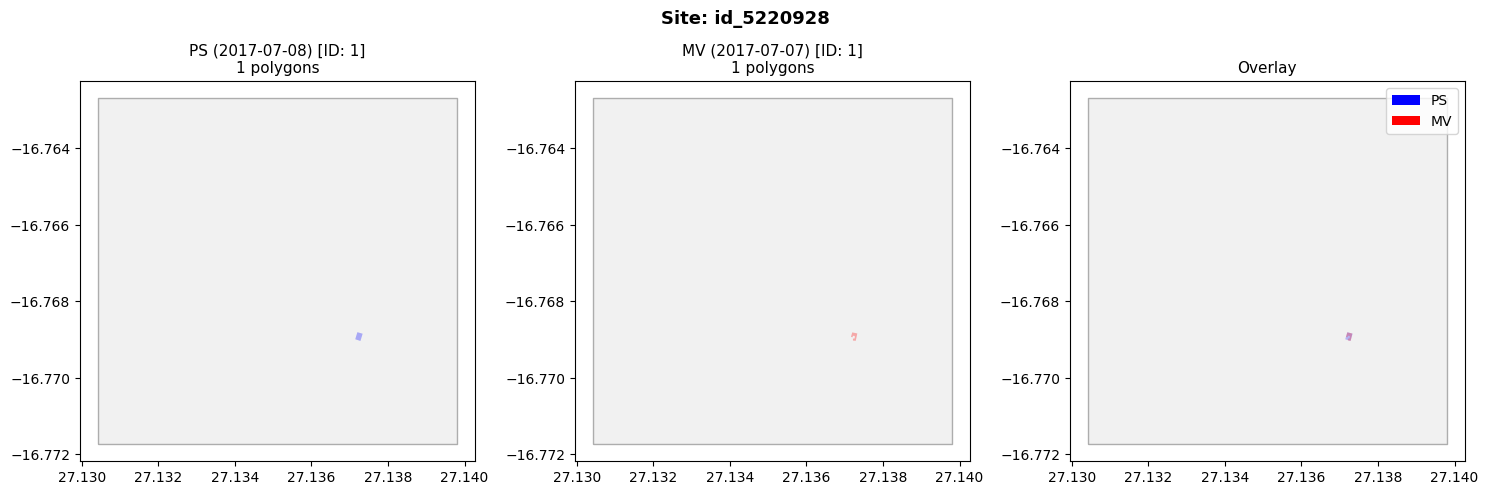

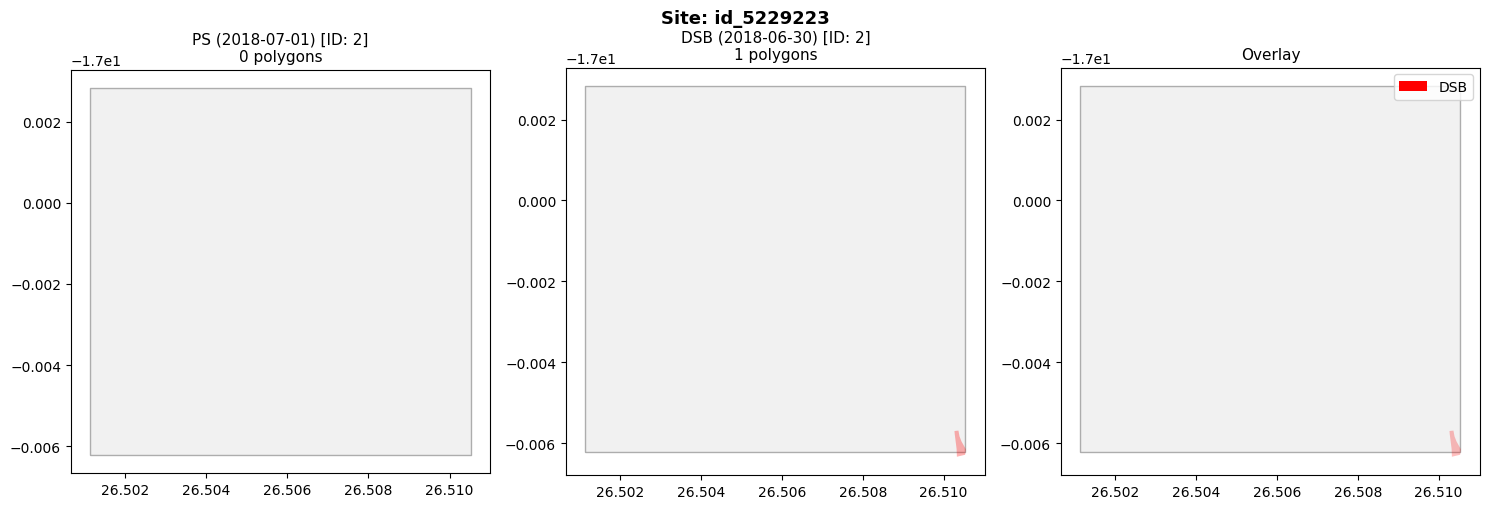

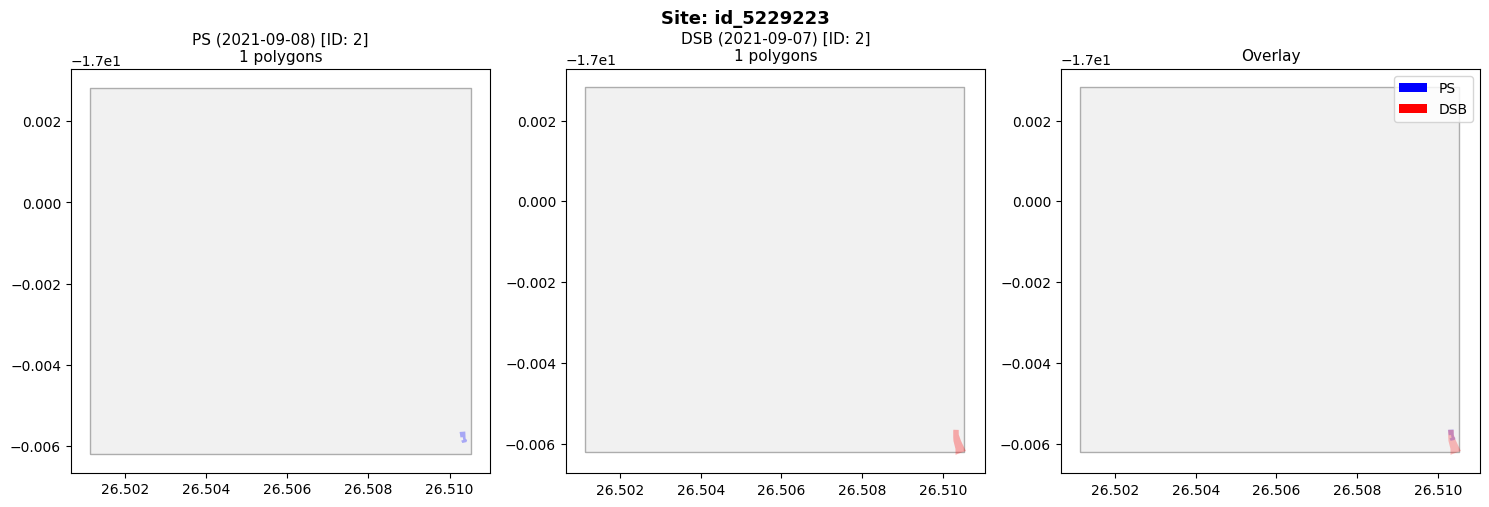

Saved 47 images to ../outputs/ps_comparisons_cert_4


In [25]:
# Plot only images where at least one labeler drew polygons
# Since output_dir is set, figures are automatically saved
print(f"\nPlotting images with polygons...")
print(f"Images will be saved to: {comparison.output_dir}")
comparison.plot_images_with_polygons()

# To plot ALL matched images (including those with no polygons):
# comparison.plot_all_images()

In [26]:
# Print summary statistics for each comparison operator
for op in comparison.comparison_operators:
    comparison.print_summary(op)


PS vs DSB Summary

Matched images: 86

Image-Level Detection:
  TP (both saw irrigation): 8
  FP (GT no irr, DSB saw irr): 4
  FN (GT saw irr, DSB no irr): 4
  TN (both saw no irrigation): 70
  Precision: 0.667
  Recall: 0.667
  F1: 0.667

Area Overlap (overall):
  Precision: 0.388
  Recall: 0.335
  F1: 0.360
  IoU: 0.219

PS vs JL Summary

Matched images: 100

Image-Level Detection:
  TP (both saw irrigation): 9
  FP (GT no irr, JL saw irr): 2
  FN (GT saw irr, JL no irr): 18
  TN (both saw no irrigation): 71
  Precision: 0.818
  Recall: 0.333
  F1: 0.474

Area Overlap (overall):
  Precision: 0.683
  Recall: 0.154
  F1: 0.251
  IoU: 0.144

PS vs KL Summary

Matched images: 47

Image-Level Detection:
  TP (both saw irrigation): 4
  FP (GT no irr, KL saw irr): 2
  FN (GT saw irr, KL no irr): 4
  TN (both saw no irrigation): 37
  Precision: 0.667
  Recall: 0.500
  F1: 0.571

Area Overlap (overall):
  Precision: 0.393
  Recall: 0.233
  F1: 0.293
  IoU: 0.171

PS vs MV Summary

Matched im

## Summary Tables

Generate summary tables with metrics compiled across all labelers, with weighted averages based on total images labeled.

In [27]:
# Generate and save summary tables
detection_table, area_table = comparison.generate_summary_tables()


IMAGE-LEVEL DETECTION METRICS
    Operator  Matched Images  Total Images Labeled  TP  FP  FN  TN  Precision   Recall       F1
         DSB              86                   588   8   4   4  70   0.666667 0.666667 0.666667
          JL             100                   582   9   2  18  71   0.818182 0.333333 0.473684
          KL              47                   681   4   2   4  37   0.666667 0.500000 0.571429
          MV              88                   623   9   5   9  65   0.642857 0.500000 0.562500
Weighted Avg             321                  2474  30  13  35 243   0.696314 0.500404 0.568822

AREA OVERLAP METRICS
    Operator  Total Images Labeled  Precision   Recall       F1      IoU
         DSB                   588   0.387597 0.335237 0.359520 0.219156
          JL                   582   0.682994 0.153990 0.251317 0.143718
          KL                   681   0.392672 0.233152 0.292582 0.171359
          MV                   623   0.702458 0.261306 0.380916 0.235266
Weight